Publication: A cell atlas of the adult Drosophila midgut, Hung et al., 2019

data: Expression Omnibus, accession no. GSE120537


In [26]:
import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad

import anndata as ad

import matplotlib.pyplot as plt
import gzip

In [186]:
#feel free to change these settings according to your needs
sc.set_figure_params(dpi=160, figsize=(4,4))
sc.settings.verbosity=0
plt.rcParams['figure.dpi'] = 160
plt.rcParams['figure.figsize'] = (4, 4)

In [4]:
# Set up R–Python interoperability using rpy2.

import anndata2ri
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()
pandas2ri.deactivate()

%load_ext rpy2.ipython

/var/folders/6b/c4vss3mj36n0nzsc7swp3_600000gn/T/ipykernel_23339/3659631106.py:9: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [6]:
%%R
library(Seurat)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Lade nötiges Paket: SeuratObject
Lade nötiges Paket: sp

Attache Paket: ‘SeuratObject’

Die folgenden Objekte sind maskiert von ‘package:base’:

    intersect, t



In [52]:
counts = pd.read_csv("../data/raw/GSE120537/GSE120537_counts.csv.gz", index_col=0)
counts

,BloodGut_G1_AAAGATGGTATCTGCA,BloodGut_G1_AAAGCAACATCAGTCA,BloodGut_G1_AACTCTTCAGCGATCC,BloodGut_G1_AACTCTTCATGTAAGA,BloodGut_G1_AAGGTTCCAACACCCG,BloodGut_G1_AATCGGTGTCAAGCGA,BloodGut_G1_ACACCCTCAAACTGTC,BloodGut_G1_ACACCGGTCACTTCAT,BloodGut_G1_ACAGCCGCAGGCAGTA,BloodGut_G1_ACATACGCAATCCAAC,...,hbc02123-CTCCTTAC:AGACGAGG-AATGAATG,hbc02123-CTCCTTAC:AATCCGGC-AATGAATG,hbc02123-CTCCTTAC:ATAAGCTA-GTTTGTTT,hbc02123-CTCCTTAC:GTTACTAG-GGCCCTTA,hbc02123-CTCCTTAC:GGCTATAA-TGACCCTC,hbc02123-CTCCTTAC:ATTCTGAG-AAATCGTT,hbc02123-CTCCTTAC:CCGATACG-CTTTAATC,hbc02123-CTCCTTAC:CCGTAGCT-CTTTAATC,hbc02123-CTCCTTAC:AATCCGGC-AGCGCCTT,hbc02123-CTCCTTAC:ACCCATGC-TCGGTACG
FBgn0000008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0000014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0000015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0000017,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0000018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBgn0286881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0286882,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0286883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FBgn0286884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
gtf_file = "../data/raw/GSE120537/dmel-all-r6.16.gtf.gz"

genes = {}

with gzip.open(gtf_file, "rt") as f:
    lines = f.readlines()[0:9]
    for line in lines:
        fields = line.split('\t')
        print(fields)

['X', 'FlyBase', 'gene', '19961297', '19969323', '.', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3";\n']
['X', 'FlyBase', 'mRNA', '19961689', '19968479', '15', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3"; transcript_id "FBtr0070000"; transcript_symbol "Nep3-RA";\n']
['X', 'FlyBase', '5UTR', '19961689', '19961845', '15', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3"; transcript_id "FBtr0070000"; transcript_symbol "Nep3-RA";\n']
['X', 'FlyBase', 'exon', '19961689', '19961845', '15', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3"; transcript_id "FBtr0070000"; transcript_symbol "Nep3-RA";\n']
['X', 'FlyBase', 'exon', '19963955', '19964071', '15', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3"; transcript_id "FBtr0070000"; transcript_symbol "Nep3-RA";\n']
['X', 'FlyBase', 'exon', '19964782', '19964944', '15', '+', '.', 'gene_id "FBgn0031081"; gene_symbol "Nep3"; transcript_id "FBtr0070000"; transcript_symbol "Nep3-RA";\n']
['X', 'FlyBase', 'exon', '1996500

In [49]:
gtf_file = "../data/raw/GSE120537/dmel-all-r6.16.gtf.gz"

gene_info = {}

with gzip.open(gtf_file, "rt") as f:
    for line in f:
        if line.startswith('#'):
            continue
        fields = line.split('\t')
        if fields[2] != 'gene':
            continue
        attrs = fields[8]

        fbgn = attrs.split('gene_id "')[1].split('"')[0]
        name = attrs.split('gene_symbol "')[1].split('"')[0]

        gene_info[fbgn] = name

In [53]:
counts.index = counts.index.map(lambda x: gene_info.get(x, x))

In [60]:
counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16986 entries, a to FBgn0286885
Columns: 10605 entries, BloodGut_G1_AAAGATGGTATCTGCA to hbc02123-CTCCTTAC:ACCCATGC-TCGGTACG
dtypes: int64(10605)
memory usage: 1.3+ GB


In [61]:
counts=counts.T
counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, BloodGut_G1_AAAGATGGTATCTGCA to hbc02123-CTCCTTAC:ACCCATGC-TCGGTACG
Columns: 16986 entries, a to FBgn0286885
dtypes: int64(16986)
memory usage: 1.3+ GB


In [62]:
meta = pd.read_csv("../data/raw/GSE120537/GSE120537_metadata.csv.gz", index_col=0)
meta.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, hbc02123-TATGCAGT:TCTAAACT-TCGACGGT to BloodGut_G4_TGACAACTCTACCTGC
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cell             10605 non-null  object 
 1   library          10605 non-null  object 
 2   nGenes           10605 non-null  int64  
 3   nUMI             10605 non-null  int64  
 4   nMito            10605 non-null  int64  
 5   pctMito          10605 non-null  float64
 6   lognGenes        10605 non-null  float64
 7   lognUMI          10605 non-null  float64
 8   complexity       10605 non-null  float64
 9   complexity_pass  10605 non-null  bool   
 10  mito_pass        10605 non-null  bool   
 11  content_pass     10605 non-null  bool   
 12  sample           10605 non-null  object 
 13  technology       10605 non-null  object 
 14  batch            10605 non-null  object 
 15  celltype         10605 non-null  object 
 16  UMAP_1

In [77]:
adata = ad.AnnData(X=counts)
adata

AnnData object with n_obs × n_vars = 10605 × 16986

In [78]:
adata.obs = meta

In [79]:
adata

AnnData object with n_obs × n_vars = 10605 × 16986
    obs: 'cell', 'library', 'nGenes', 'nUMI', 'nMito', 'pctMito', 'lognGenes', 'lognUMI', 'complexity', 'complexity_pass', 'mito_pass', 'content_pass', 'sample', 'technology', 'batch', 'celltype', 'UMAP_1', 'UMAP_2'

In [80]:
np.median(adata.obs['nUMI'])

964.0

In [81]:
np.median(adata.obs['nGenes'])

309.0

The filtering criteria is based on the https://ftp.ncbi.nlm.nih.gov/geo/series/GSE120nnn/GSE120537/suppl/GSE120537%5Fmetadata%2Dcode%2Dbook.md.txt.gz
that is applied to the dataset.

- complexity_pass = complexity exceeds threshold of 0.70
- mito_pass = mitochondrial percentage is less than 0.50

In [91]:
# just to check
print(f'maximum mito percentage: {np.max(adata.obs["pctMito"])}')
print(f'minimum complexity: {np.min(adata.obs["complexity"])}')

maximum mito percentage: 49.9712478435883
minimum complexity: 0.704545500647087


In [92]:
nan_string_in_var_names = adata.var_names.str.lower() == 'nan'
print("String 'nan' in var_names:", nan_string_in_var_names.any())

String 'nan' in var_names: True


In [93]:
# Filtering out 'nan' var_names
if nan_string_in_var_names.any():
    # Filter out those variables
    valid_var_indices = ~nan_string_in_var_names  # Invert the boolean mask
    adata = adata[:, valid_var_indices].copy()  # Apply the filter to columns

In [94]:
adata

AnnData object with n_obs × n_vars = 10605 × 16985
    obs: 'cell', 'library', 'nGenes', 'nUMI', 'nMito', 'pctMito', 'lognGenes', 'lognUMI', 'complexity', 'complexity_pass', 'mito_pass', 'content_pass', 'sample', 'technology', 'batch', 'celltype', 'UMAP_1', 'UMAP_2'

In [95]:
adata.layers["raw_counts"]=adata.X.copy()

In [96]:
adata.raw=adata.copy()

In [97]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [98]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000, subset=True)
adata

/Users/royaab/py310/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:215: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


AnnData object with n_obs × n_vars = 10605 × 4000
    obs: 'cell', 'library', 'nGenes', 'nUMI', 'nMito', 'pctMito', 'lognGenes', 'lognUMI', 'complexity', 'complexity_pass', 'mito_pass', 'content_pass', 'sample', 'technology', 'batch', 'celltype', 'UMAP_1', 'UMAP_2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'raw_counts'

In [99]:
adata.layers["logcounts"]=adata.X.copy()

In [183]:
adata_seu = adata.copy()

In [184]:
sc.tl.pca(adata_seu)
sc.pp.neighbors(adata_seu)
sc.tl.umap(adata_seu)


NameError: name 'seu' is not defined

/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/pyth

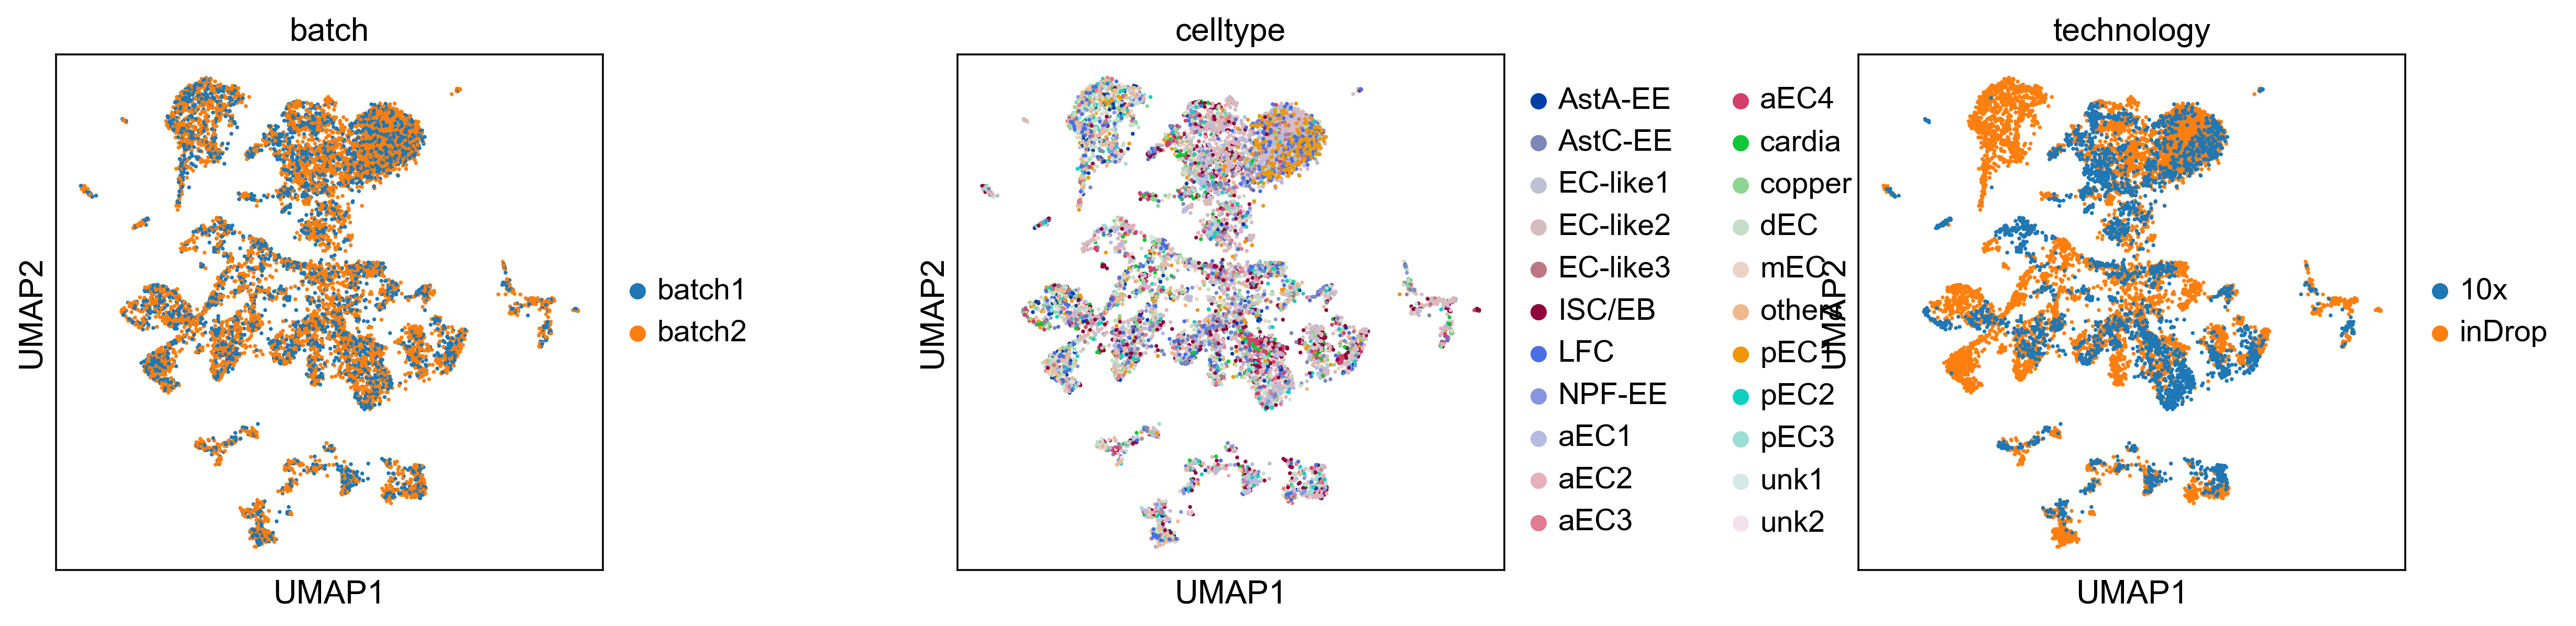

In [188]:
sc.pl.umap(adata_seu, color=[batch_key, label_key, tech_key], wspace=0.5)

In [160]:
batch_key = "batch"
label_key = "celltype"
tech_key = "technology"

In [161]:
adata_seu.obs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, hbc02123-TATGCAGT:TCTAAACT-TCGACGGT to BloodGut_G4_TGACAACTCTACCTGC
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cell             10605 non-null  object 
 1   library          10605 non-null  object 
 2   nGenes           10605 non-null  int64  
 3   nUMI             10605 non-null  int64  
 4   nMito            10605 non-null  int64  
 5   pctMito          10605 non-null  float64
 6   lognGenes        10605 non-null  float64
 7   lognUMI          10605 non-null  float64
 8   complexity       10605 non-null  float64
 9   complexity_pass  10605 non-null  bool   
 10  mito_pass        10605 non-null  bool   
 11  content_pass     10605 non-null  bool   
 12  sample           10605 non-null  object 
 13  technology       10605 non-null  object 
 14  batch            10605 non-null  object 
 15  celltype         10605 non-null  object 
 16  UMAP_1

In [162]:
keys = [batch_key, label_key, tech_key]

for key in keys:
    adata_seu.obs[key] = adata_seu.obs[key].astype(str)

In [163]:
adata_seu.obs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, hbc02123-TATGCAGT:TCTAAACT-TCGACGGT to BloodGut_G4_TGACAACTCTACCTGC
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cell             10605 non-null  object 
 1   library          10605 non-null  object 
 2   nGenes           10605 non-null  int64  
 3   nUMI             10605 non-null  int64  
 4   nMito            10605 non-null  int64  
 5   pctMito          10605 non-null  float64
 6   lognGenes        10605 non-null  float64
 7   lognUMI          10605 non-null  float64
 8   complexity       10605 non-null  float64
 9   complexity_pass  10605 non-null  bool   
 10  mito_pass        10605 non-null  bool   
 11  content_pass     10605 non-null  bool   
 12  sample           10605 non-null  object 
 13  technology       10605 non-null  object 
 14  batch            10605 non-null  object 
 15  celltype         10605 non-null  object 
 16  UMAP_1

In [164]:
%%R -i adata_seu
adata_seu

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/functools.py:889: NotConvertedWarning: Conversion 'py2rpy' not defined for objects of type '<class 'NoneType'>'
  return dispatch(args[0].__class__)(*args, **kw)


class: SingleCellExperiment 
dim: 4000 10605 
metadata(2): log1p hvg
assays(3): X raw_counts logcounts
rownames(4000): a Ace ... FBgn0286831 FBgn0286869
rowData names(4): highly_variable means dispersions dispersions_norm
colnames(10605): hbc02123-TATGCAGT:TCTAAACT-TCGACGGT
  hbc02123-TATGCAGT:AACAGAAC-GGGAAGGT ... BloodGut_G3_GTCACGGGTTGAGGTG
  BloodGut_G4_TGACAACTCTACCTGC
colData names(18): cell library ... UMAP_1 UMAP_2
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):


In [165]:
%%R -i adata_seu
seurat <- as.Seurat(adata_seu, counts = "raw_counts", data = "logcounts")
seurat

An object of class Seurat 
4000 features across 10605 samples within 1 assay 
Active assay: originalexp (4000 features, 0 variable features)
 2 layers present: counts, data


In [167]:
%%R
#indrop = subset(seurat, subset = technology == "inDrop")
#indrop = NormalizeData(object = indrop)
#indrop = ScaleData(object = indrop)
#indrop = FindVariableFeatures(indrop, do.plot = FALSE)
#tenx = subset(seurat, subset = technology == "10x")
#tenx = NormalizeData(object = tenx)
#tenx = ScaleData(object = tenx)
#tenx = FindVariableFeatures(tenx, do.plot = FALSE)
#hvf = union(VariableFeatures(indrop), VariableFeatures(tenx))
batch_list = SplitObject(seurat, split.by="technology")
anchors = FindIntegrationAnchors(batch_list, anchor.features=rownames(seurat), dims=1:30)
integrated = IntegrateData(anchorset = anchors, dims = 1:30)
DefaultAssay(integrated) = "integrated"

  |                                                  | 0 % ~calculating   |+++++++++++++++++++++++++                         | 50% ~01s           |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  
  |                                                  | 0 % ~calculating   |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01m 59s


Scaling features for provided objects
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 8158 anchors
Filtering anchors
	Retained 6610 anchors
Merging dataset 2 into 1
Extracting anchors for merged samples
Finding integration vectors
Finding integration vector weights
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Integrating data
Warnung: Layer counts isn't present in the assay object; returning NULL


In [168]:
%%R
integrated

An object of class Seurat 
8000 features across 10605 samples within 2 assays 
Active assay: integrated (4000 features, 4000 variable features)
 1 layer present: data
 1 other assay present: originalexp


In [112]:
%%R
tenx

An object of class Seurat 
4000 features across 2979 samples within 1 assay 
Active assay: originalexp (4000 features, 2000 variable features)
 3 layers present: counts, data, scale.data


In [113]:
%%R
integrated_expr <- GetAssayData(integrated)
dim(integrated_expr)

[1]  2000 10605


In [136]:
%%R -o common_genes
genes_obj1 <- rownames(seurat)
genes_obj2 <- rownames(integrated)

# Identify the common genes
common_genes <- genes_obj1[genes_obj1 %in% genes_obj2]
seurat <- subset(seurat, features = common_genes)

In [137]:
len(common_genes)

2000

In [138]:
%%R
seurat

An object of class Seurat 
2000 features across 10605 samples within 1 assay 
Active assay: originalexp (2000 features, 0 variable features)
 2 layers present: counts, data


In [169]:
%%R -o integrated_expr
# Extract the integrated expression matrix
integrated_expr <- GetAssayData(integrated)
# Make sure the rows and columns are in the same order as the original object
integrated_expr <- integrated_expr[rownames(seurat), colnames(seurat)]
# Transpose the matrix to AnnData format
integrated_expr <- t(integrated_expr)
print(integrated_expr[1:10, 1:10])

10 x 10 sparse Matrix of class "dgCMatrix"
                                                               
hbc02123-TATGCAGT:TCTAAACT-TCGACGGT . . . . . . . . . .        
hbc02123-TATGCAGT:AACAGAAC-GGGAAGGT . . . . . . . . . .        
hbc02123-TATGCAGT:GTATACGT-CCTATTCA . . . . . . . . . .        
hbc02123-TATGCAGT:ACTGCTGG-TTGAGGGT . . . . . . . . . .        
hbc02123-TATGCAGT:ACGTAAAC-CCTATTCA . . . . . . . . . .        
hbc02123-TATGCAGT:CTGCTAGA-ATATCTTC . . . . . . . . . 0.2333422
hbc02123-TATGCAGT:TATCTGTC-TCTAGCAG . . . . . . . . . .        
hbc02123-TATGCAGT:GCCAAAGC-AACACACG . . . . . . . . . .        
hbc02123-TATGCAGT:ATTATTCG-CCCTTGGT . . . . . . . . . .        
hbc02123-TATGCAGT:TGGCTAGT-AACCCTTG . . . . . . . . . .        


  [[ suppressing 10 column names ‘a’, ‘Ace’, ‘Acph-1’ ... ]]


In [170]:
integrated_expr.toarray()

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         6.58919394e-01,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  4.93065870e-04, ...,
         3.76806964e-02,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  1.98566632e-02,  0.00000000e+00, ...,
        -7.40151494e-02,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  2.72287660e-03,  4.31889073e-03, ...,
         1.05895939e+00,  5.69531394e-03,  0.00000000e+00]])

In [142]:
%%R
# Check orders
print(head(rownames(integrated_expr)))
print(head(colnames(integrated_expr)))


[1] "hbc02123-TATGCAGT:TCTAAACT-TCGACGGT" "hbc02123-TATGCAGT:AACAGAAC-GGGAAGGT"
[3] "hbc02123-TATGCAGT:GTATACGT-CCTATTCA" "hbc02123-TATGCAGT:ACTGCTGG-TTGAGGGT"
[5] "hbc02123-TATGCAGT:ACGTAAAC-CCTATTCA" "hbc02123-TATGCAGT:CTGCTAGA-ATATCTTC"
[1] "a"       "Ace"     "mAChR-A" "Act57B"  "Act88F"  "Adh"    


In [143]:
%%R
# Check orders
print(head(rownames(seurat)))
print(head(colnames(seurat)))


[1] "a"       "Ace"     "mAChR-A" "Act57B"  "Act88F"  "Adh"    
[1] "hbc02123-TATGCAGT:TCTAAACT-TCGACGGT" "hbc02123-TATGCAGT:AACAGAAC-GGGAAGGT"
[3] "hbc02123-TATGCAGT:GTATACGT-CCTATTCA" "hbc02123-TATGCAGT:ACTGCTGG-TTGAGGGT"
[5] "hbc02123-TATGCAGT:ACGTAAAC-CCTATTCA" "hbc02123-TATGCAGT:CTGCTAGA-ATATCTTC"


In [144]:
%%R
# Check orders
print(head(rownames(integrated_expr)))
print(head(colnames(integrated_expr)))

# Ensure that integrated_expr has genes as rows and cells as columns
# (if this is not already the case, transpose back)
if (!identical(rownames(integrated_expr), rownames(adata_seu))) {
    integrated_expr <- t(integrated_expr)  # transpose only if necessary
}

# Output the order for verification in Python
write.csv(rownames(integrated_expr), "integrated_genes_order.csv")
write.csv(colnames(integrated_expr), "integrated_cells_order.csv")

[1] "hbc02123-TATGCAGT:TCTAAACT-TCGACGGT" "hbc02123-TATGCAGT:AACAGAAC-GGGAAGGT"
[3] "hbc02123-TATGCAGT:GTATACGT-CCTATTCA" "hbc02123-TATGCAGT:ACTGCTGG-TTGAGGGT"
[5] "hbc02123-TATGCAGT:ACGTAAAC-CCTATTCA" "hbc02123-TATGCAGT:CTGCTAGA-ATATCTTC"
[1] "a"       "Ace"     "mAChR-A" "Act57B"  "Act88F"  "Adh"    


In [147]:
pd.read_csv("integrated_genes_order.csv").iloc[:, 1]

0                 a
1               Ace
2           mAChR-A
3            Act57B
4            Act88F
           ...     
1995    FBgn0286507
1996    FBgn0286508
1997    FBgn0286785
1998    FBgn0286831
1999    FBgn0286869
Name: x, Length: 2000, dtype: object

In [148]:
# Load the orders
gene_order = pd.read_csv("integrated_genes_order.csv").iloc[:,1]
cell_order = pd.read_csv("integrated_cells_order.csv").iloc[:,1]

# Assuming 'integrated_expr' is now in Python, check if alignment is needed
print(integrated_expr.shape)
print(adata_seu.shape)

# Align gene order
adata_seu = adata_seu[:, adata_seu.var_names.isin(gene_order)].copy()
adata_seu = adata_seu[:, gene_order]

# Align cell order
adata_seu = adata_seu[cell_order, :]
adata_seu

(10605, 2000)
(10605, 2000)


View of AnnData object with n_obs × n_vars = 10605 × 2000
    obs: 'cell', 'library', 'nGenes', 'nUMI', 'nMito', 'pctMito', 'lognGenes', 'lognUMI', 'complexity', 'complexity_pass', 'mito_pass', 'content_pass', 'sample', 'technology', 'batch', 'celltype', 'UMAP_1', 'UMAP_2', 'simple_celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'celltype_colors', 'technology_colors', 'simple_celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts', 'logcounts', 'seurat'
    obsp: 'distances', 'connectivities'

In [149]:
# Ensure the data type is correct (e.g., float)
if integrated_expr.dtype != np.float32:
    integrated_expr = integrated_expr.astype(np.float32)

In [150]:
adata_seu.layers["seurat"] = integrated_expr

/var/folders/6b/c4vss3mj36n0nzsc7swp3_600000gn/T/ipykernel_23339/1096187236.py:1: ImplicitModificationWarning: Setting element `.layers['seurat']` of view, initializing view as actual.
  adata_seu.layers["seurat"] = integrated_expr


In [171]:
adata_seu.X = integrated_expr

In [173]:
adata_seu.layers["seurat"] = integrated_expr

/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/pyth

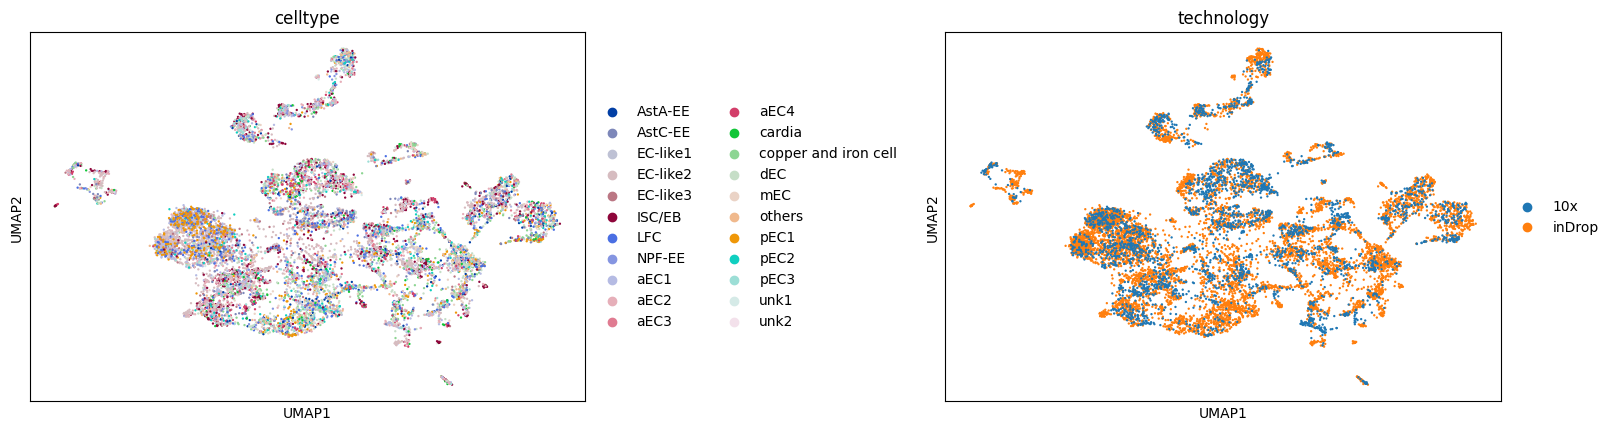

In [174]:
sc.tl.pca(adata_seu, n_comps=30)
sc.pp.neighbors(adata_seu, n_pcs=30)
sc.tl.umap(adata_seu)
sc.pl.umap(adata_seu, color=[label_key, "technology"], wspace=0.5)

In [175]:
sc.tl.umap(adata_seu, min_dist=0.3)


/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/pyth

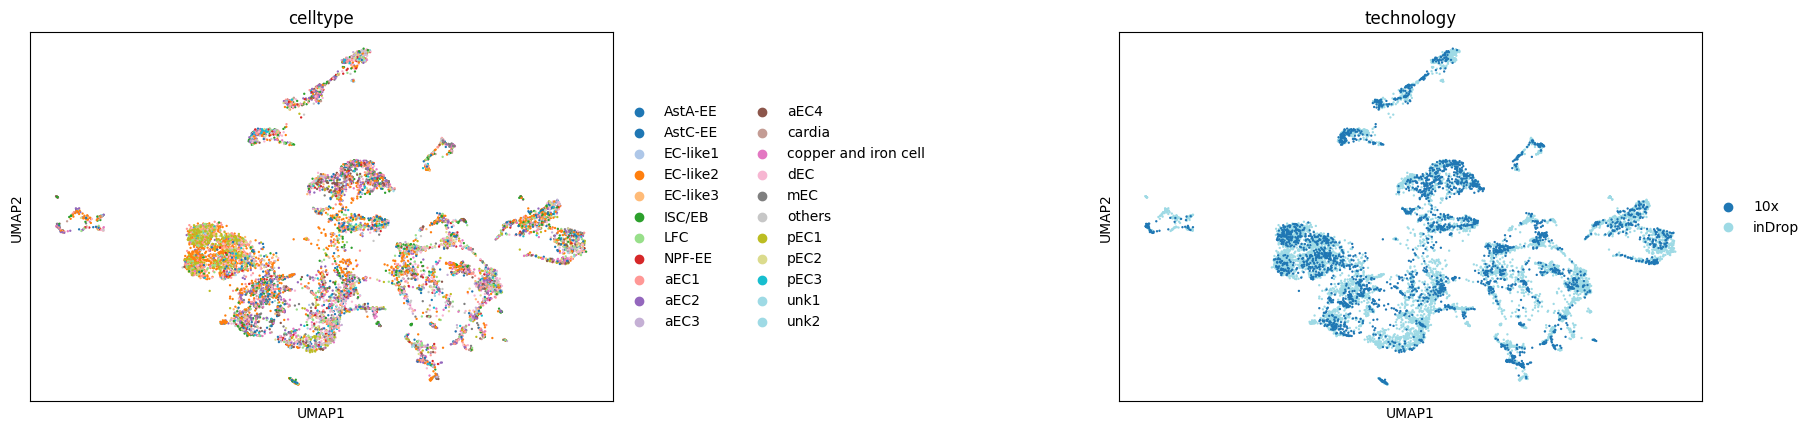

In [176]:
sc.pl.umap(adata_seu, color=[label_key, "technology"], wspace=0.7, palette="tab20")

In [177]:
simple_cell = {"aEC1":"aEC", "aEC2":"aEC", "aEC3":"aEC", "aEC4":"aEC", "pEC1":"pEC", "pEC2":"pEC", 
               "pEC3":"pEC"}

In [178]:
adata_seu.obs["simple_celltype"]=adata_seu.obs["celltype"].map(simple_cell).fillna(adata_seu.obs["celltype"])

/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


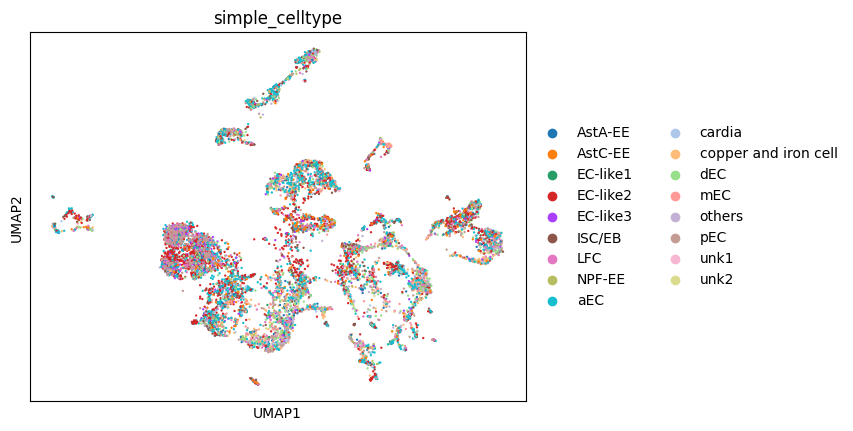

In [179]:
sc.pl.umap(adata_seu, color="simple_celltype")

In [180]:
traj = adata_seu[adata_seu.obs["simple_celltype"].isin(["ISC/EB", "dEC", "aEC", "mEC", "pEC"])]
traj

View of AnnData object with n_obs × n_vars = 5458 × 4000
    obs: 'cell', 'library', 'nGenes', 'nUMI', 'nMito', 'pctMito', 'lognGenes', 'lognUMI', 'complexity', 'complexity_pass', 'mito_pass', 'content_pass', 'sample', 'technology', 'batch', 'celltype', 'UMAP_1', 'UMAP_2', 'simple_celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'celltype_colors', 'technology_colors', 'simple_celltype_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts', 'logcounts', 'seurat'
    obsp: 'distances', 'connectivities'

/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/royaab/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


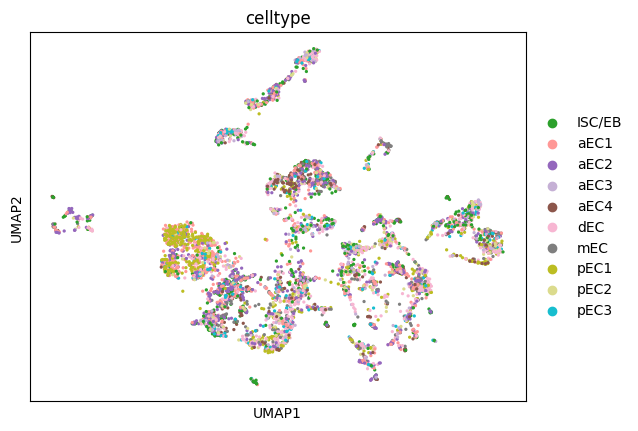

In [181]:
sc.pl.umap(traj, color="celltype")

In [115]:
sc.pp.pca(traj, n_comps=30)
sc.pp.neighbors(traj, n_pcs=30)
sc.tl.umap(traj)

/Users/royaab/miniconda3/envs/new_scanpy/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca


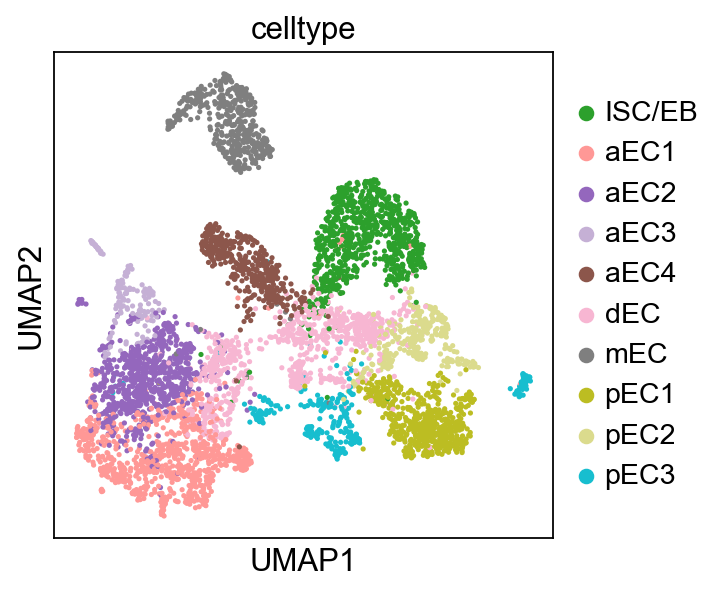

In [116]:
sc.pl.umap(traj, color="celltype")

In [120]:
traj.X=traj.layers["logcounts"].copy()

KeyError: 'Could not find key klu in .var_names or .obs.columns.'

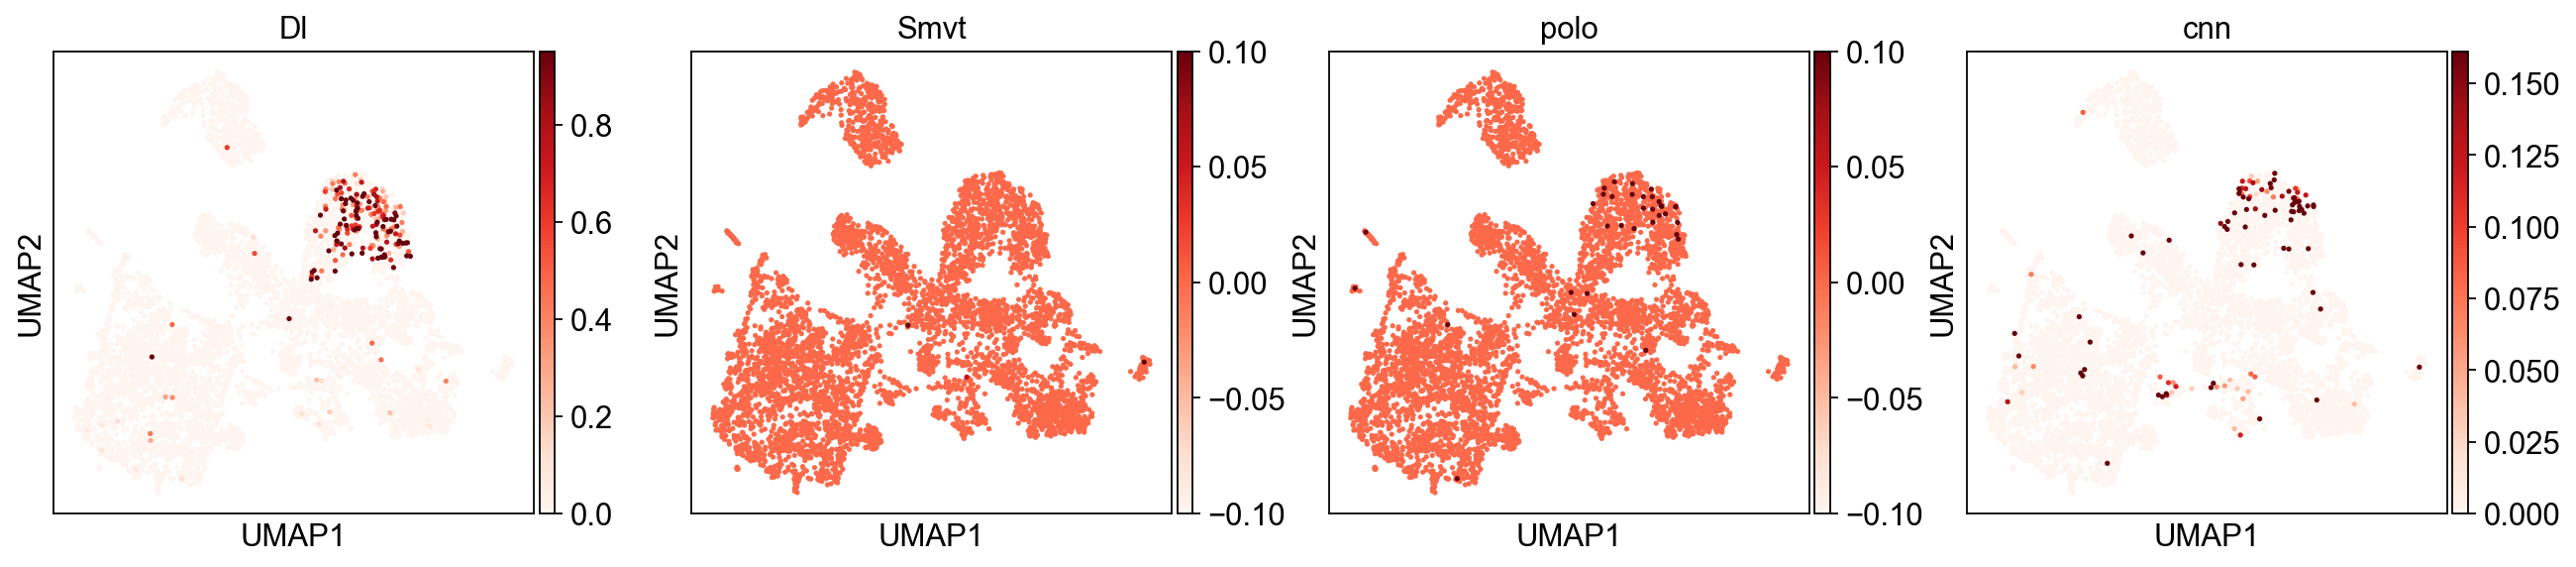

In [123]:
sc.pl.umap(traj, color=["Dl", "Smvt", "polo", "cnn", "klu"], use_raw=False, cmap="Reds", vmax="p99")

In [125]:
adata=sc.read('Adult_complete.h5ad')
adata

AnnData object with n_obs × n_vars = 10605 × 2000
    obs: 'celltype', 'batch', 'technology', 'simple_celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'simple_celltype_colors', 'technology_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'logcounts', 'raw_counts', 'seurat'
    obsp: 'connectivities', 'distances'

In [127]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)

/Users/grosshanslab/python/py310/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/grosshanslab/python/py310/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/grosshanslab/python/py310/lib/python3.10/site-packages/umap/distanc

In [128]:
sc.tl.umap(adata, min_dist=0.5, spread=1.2)

/Users/grosshanslab/python/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


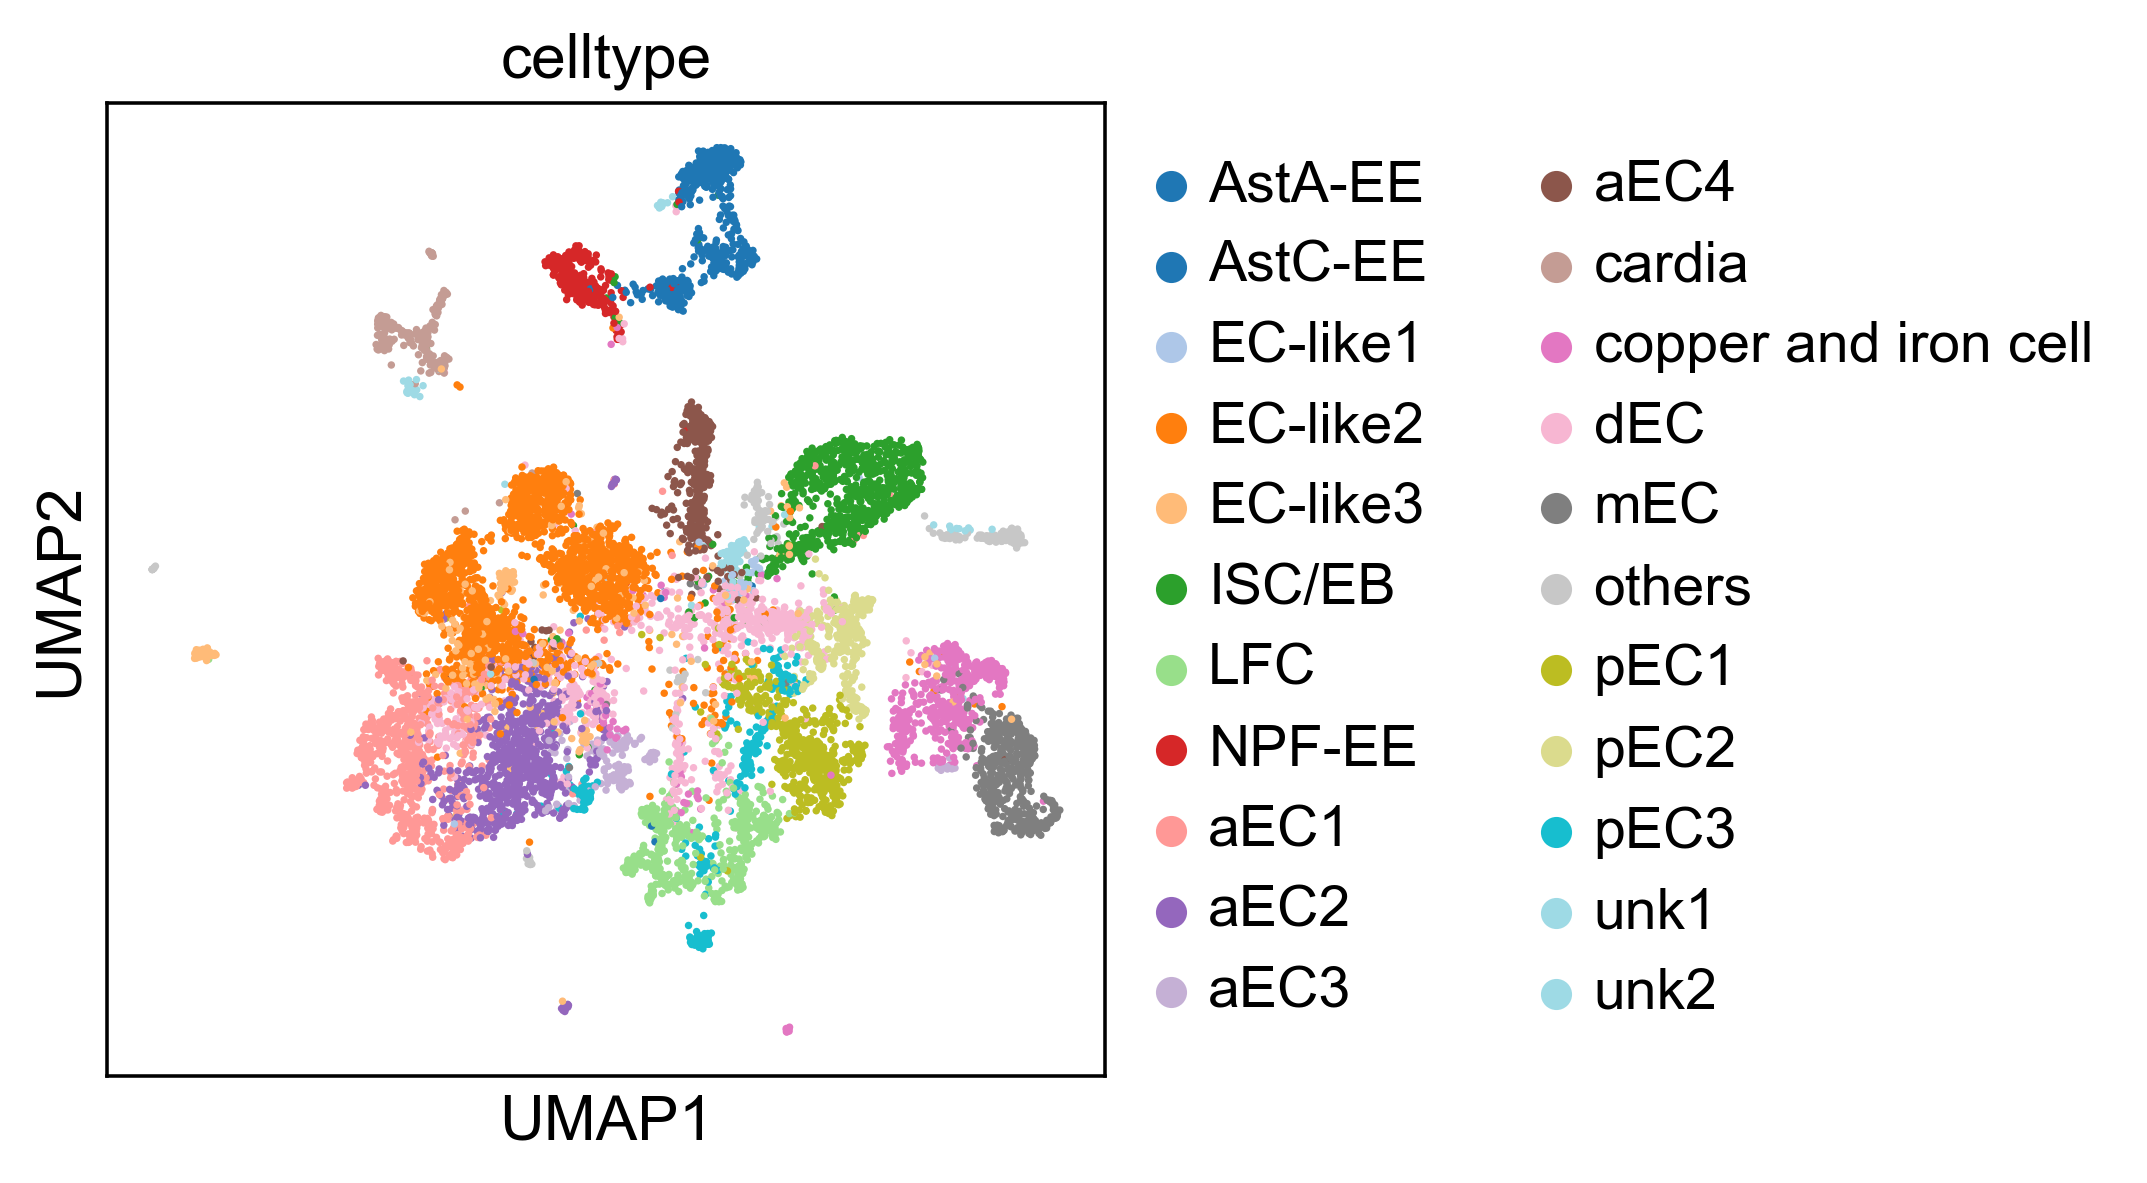

In [129]:
sc.pl.umap(adata, color='celltype')

In [5]:
traj=sc.read('Adult_trajectory.h5ad')
traj

AnnData object with n_obs × n_vars = 5458 × 2000
    obs: 'celltype', 'batch', 'technology', 'simple_celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'batch_colors', 'celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'simple_celltype_colors', 'technology_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'logcounts', 'raw_counts', 'seurat'
    obsp: 'connectivities', 'distances'

/Users/grosshanslab/python/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


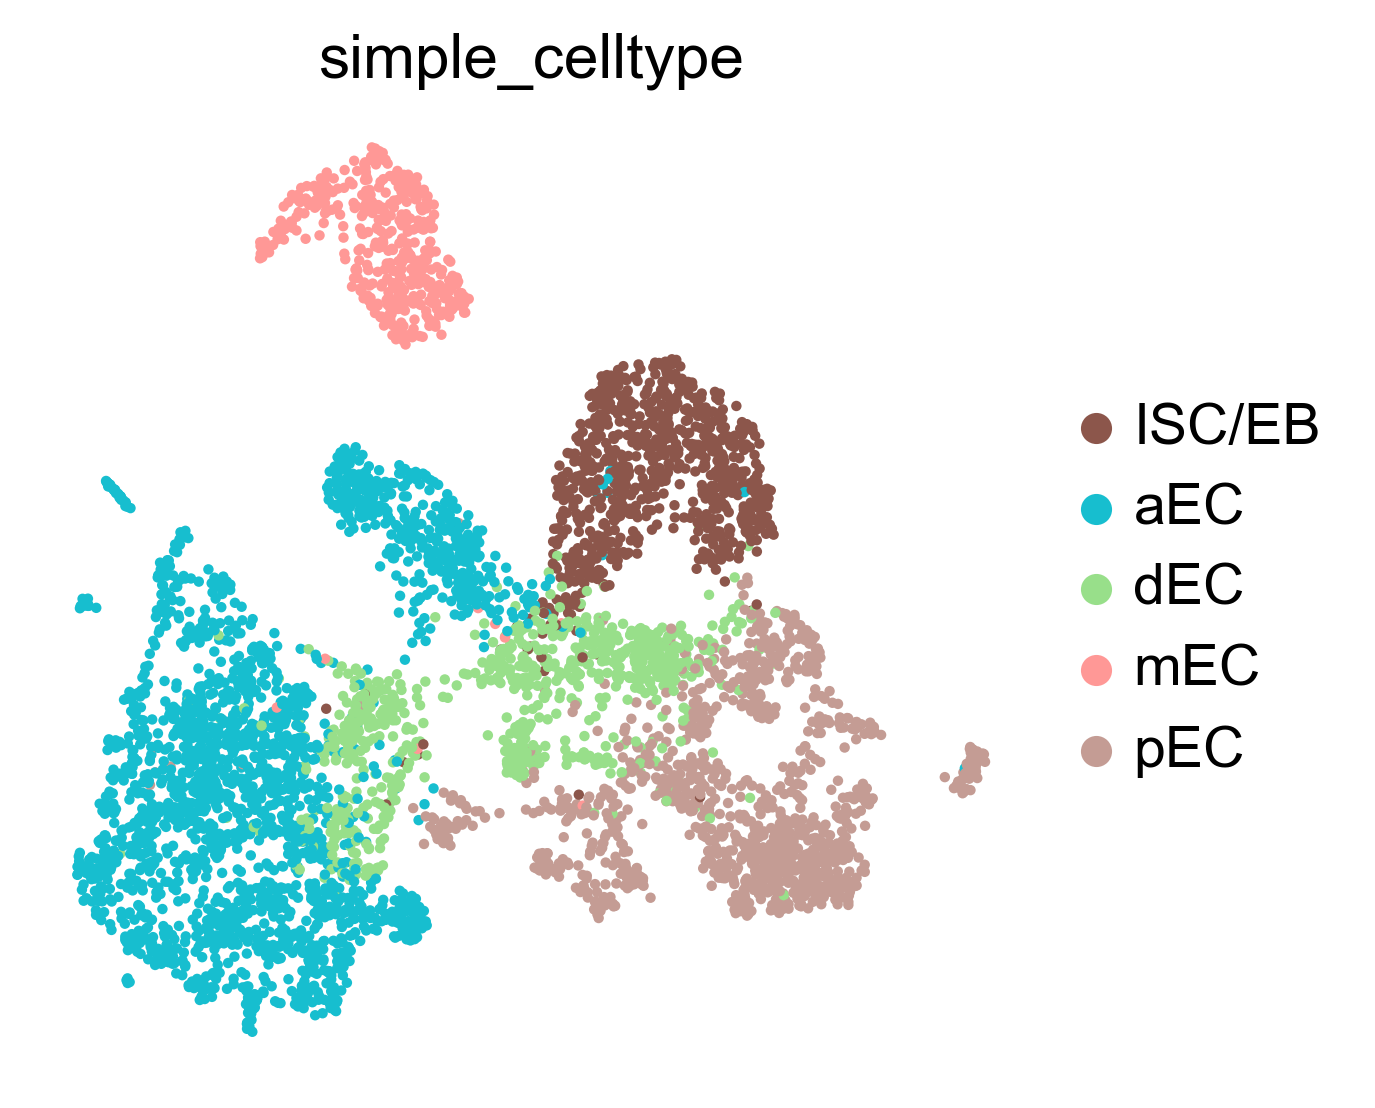

In [33]:
sc.pl.umap(traj, color='simple_celltype', frameon=False)

In [82]:
traj=traj[~traj.obs['simple_celltype'].isin(['dEC'])]

/Users/grosshanslab/python/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


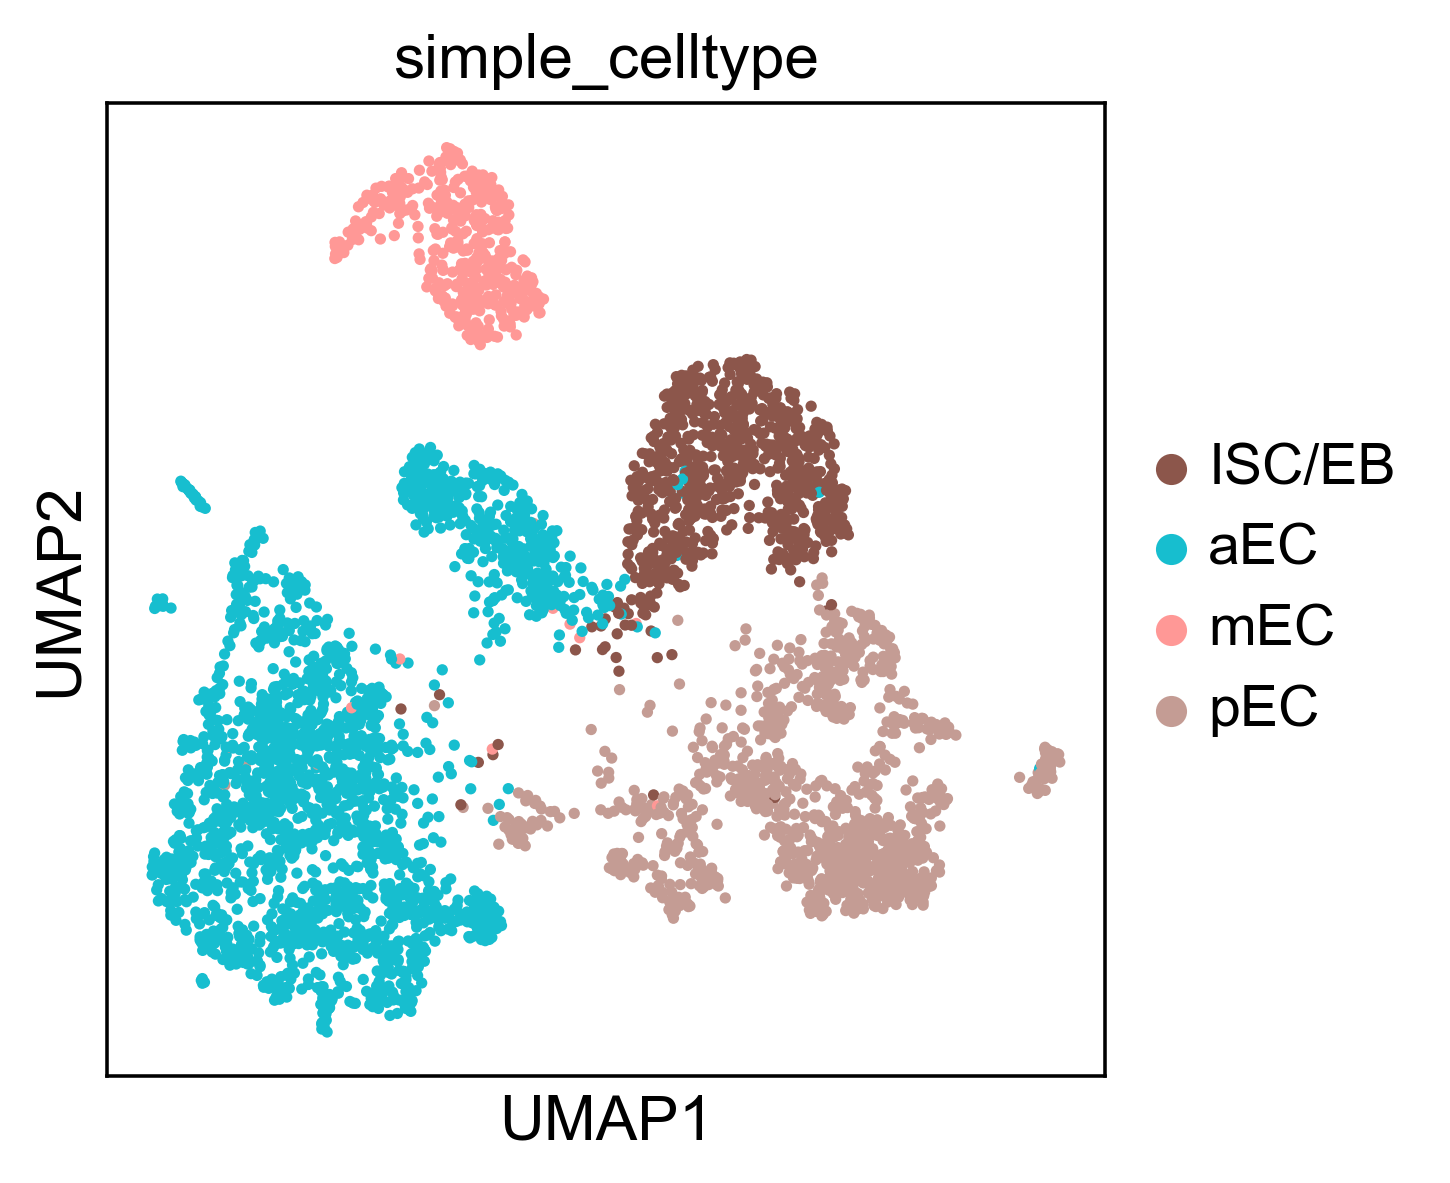

In [124]:
sc.pl.umap(traj, color='simple_celltype')

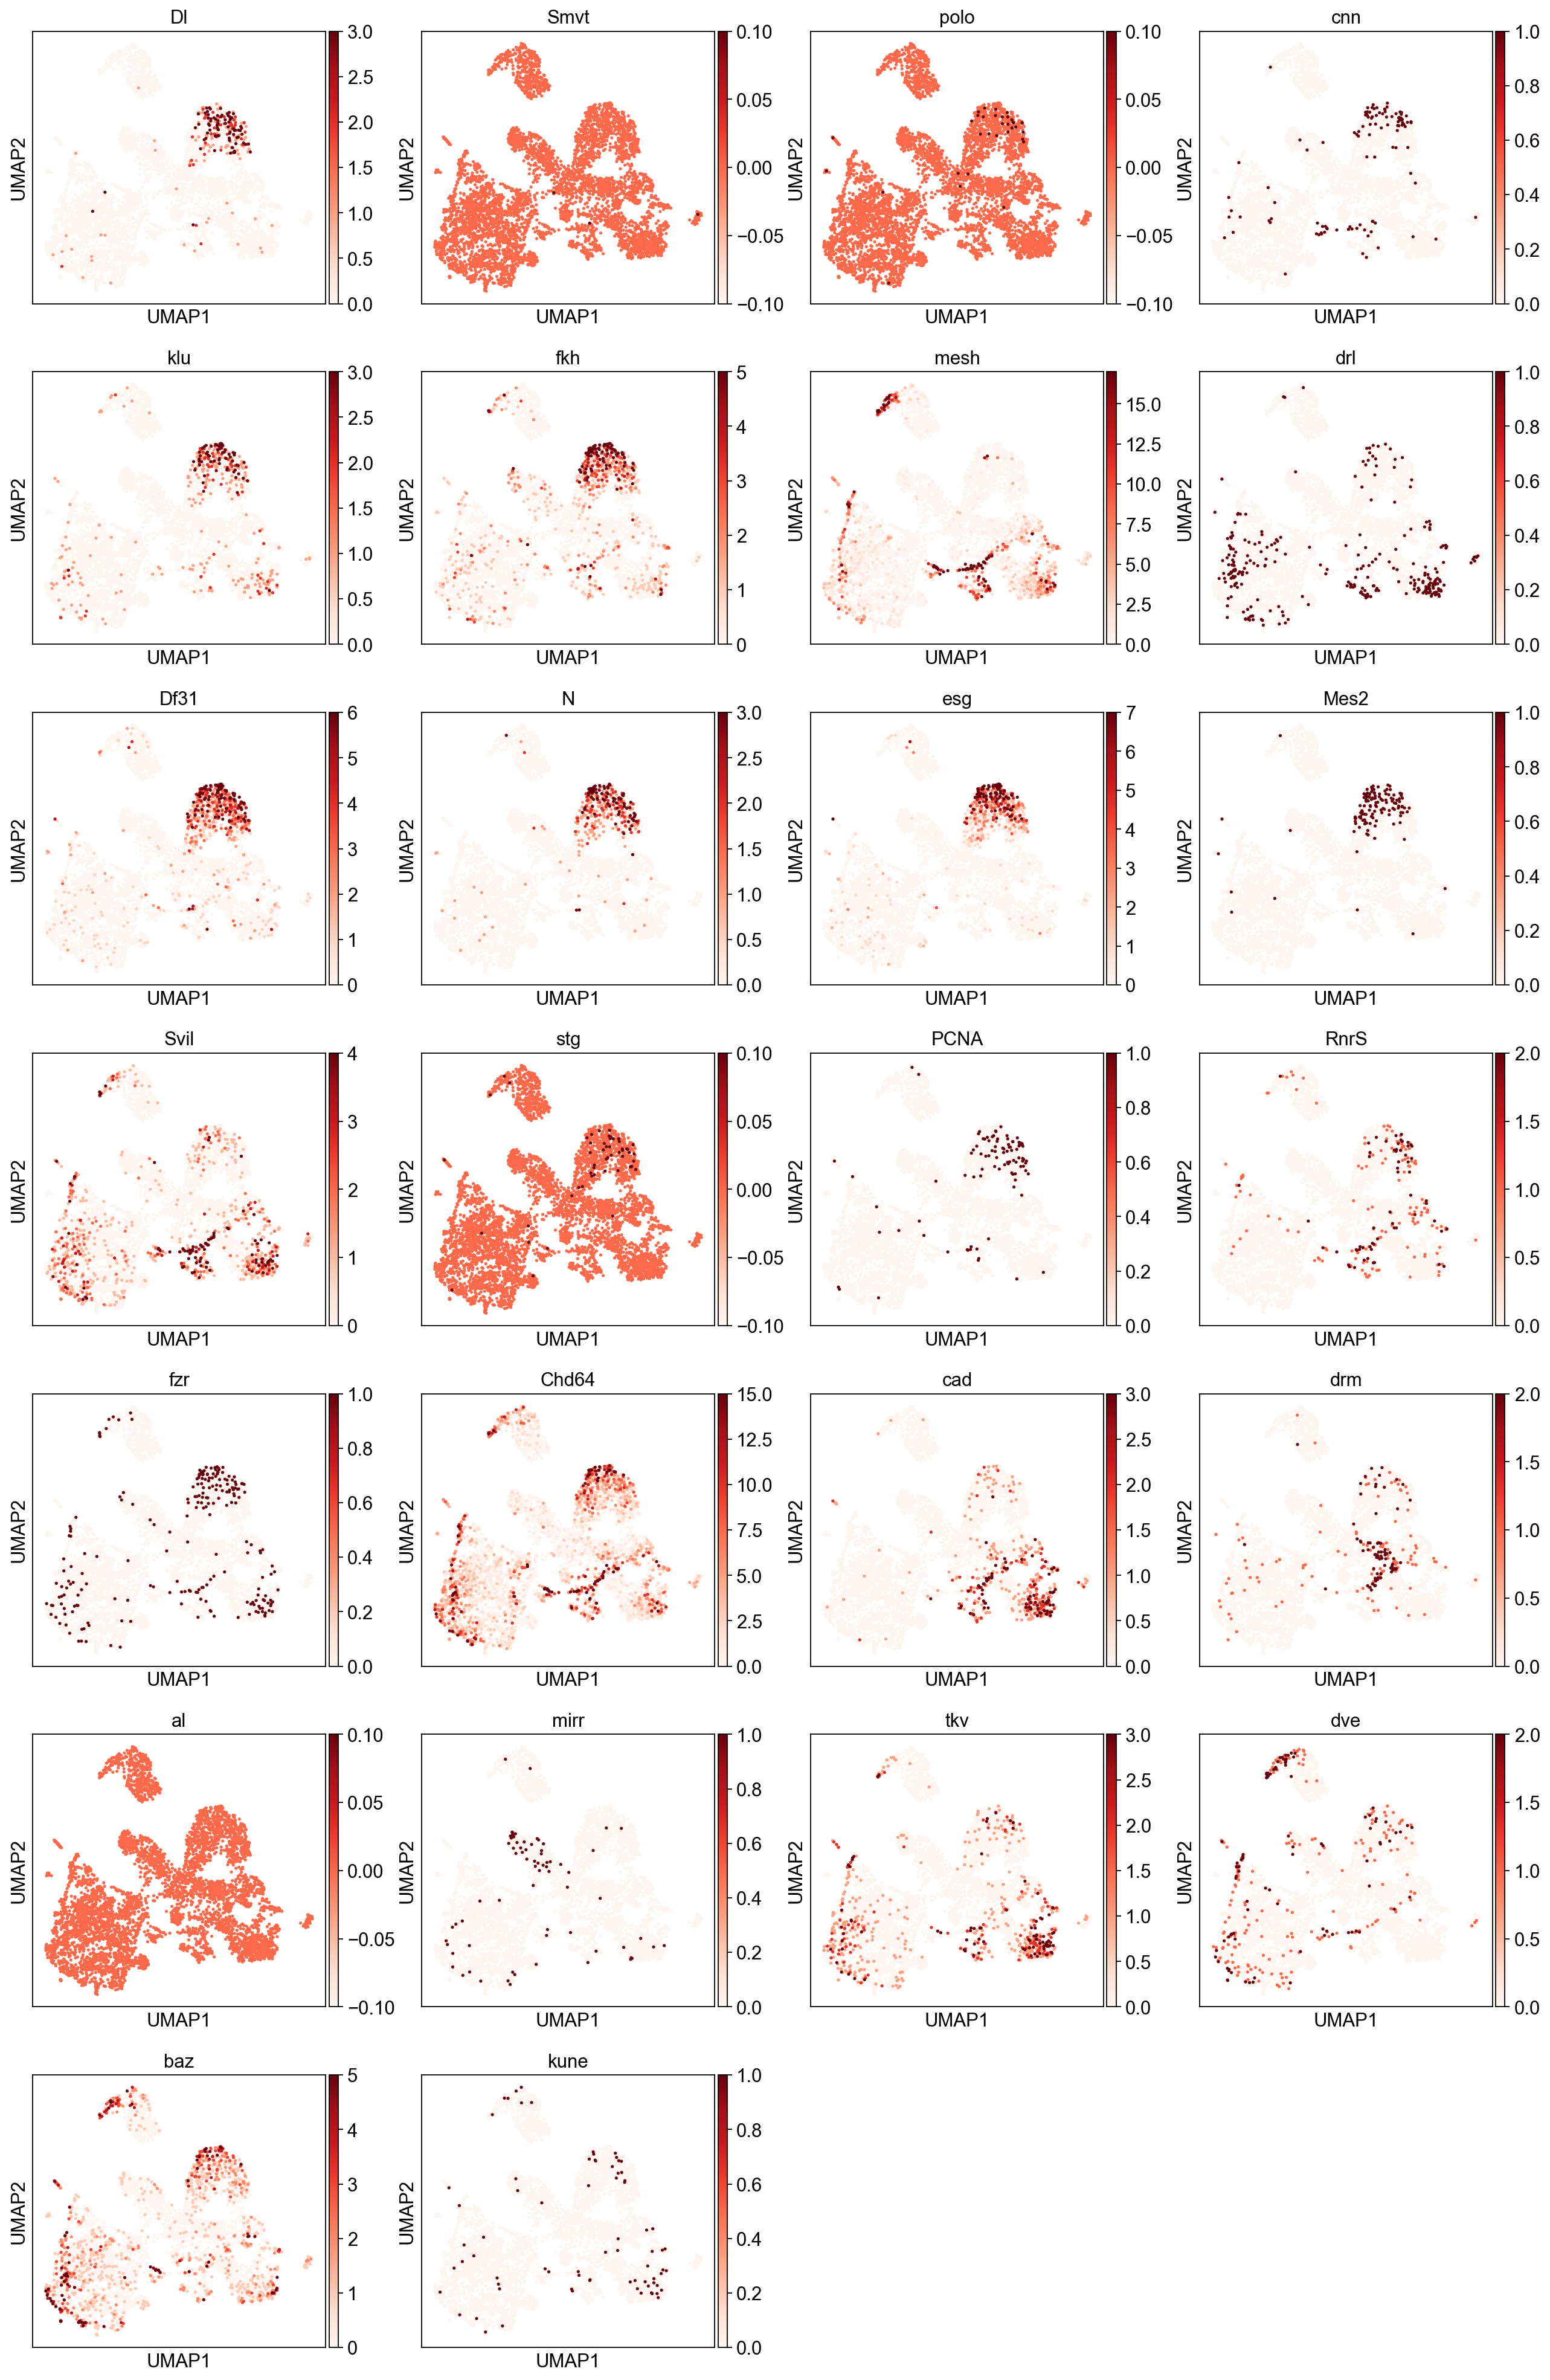

In [6]:
sc.pl.umap(traj, color=["Dl", "Smvt", "polo", "cnn", "klu", "fkh", "mesh", "drl", "Df31", "N", "esg", 
                        "Mes2", "Svil", "stg", "PCNA", "RnrS", "fzr", "Chd64", "cad", "drm", "al", "mirr", 
                        "tkv","dve", "baz", "kune"], use_raw=True, cmap="Reds", vmax="p99")

In [139]:
traj.write("Adult_trajectory.h5ad")

In [140]:
adata_seu.write("Adult_complete.h5ad")

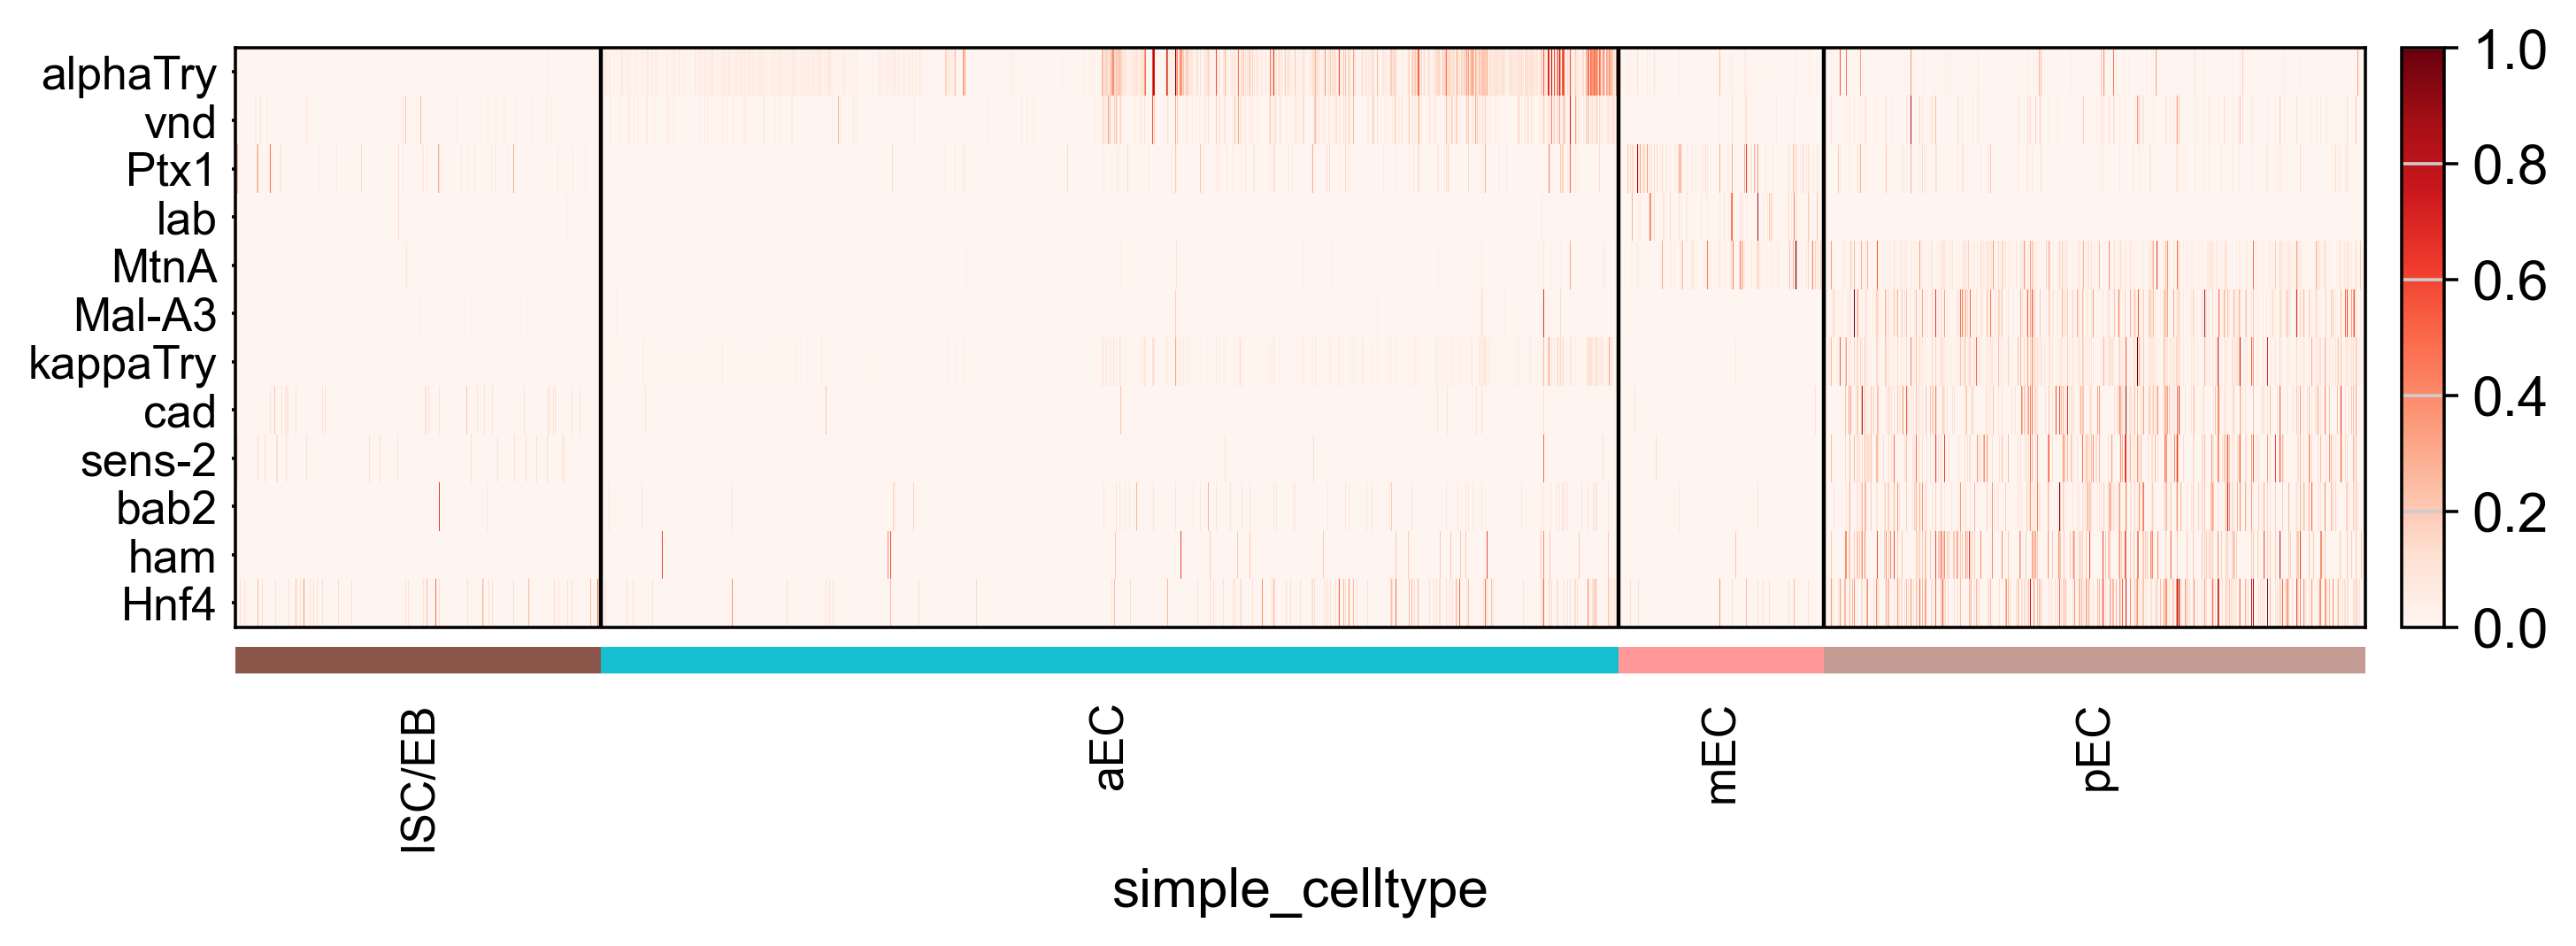

In [123]:
sc.pl.heatmap(traj,var_names=['alphaTry', 'vnd', 'Ptx1','lab', 'MtnA', 'Mal-A3', 'kappaTry', 'cad', 'sens-2', 'bab2', 
                              'ham', 'Hnf4'], 
              groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=1, figsize=(10,3))

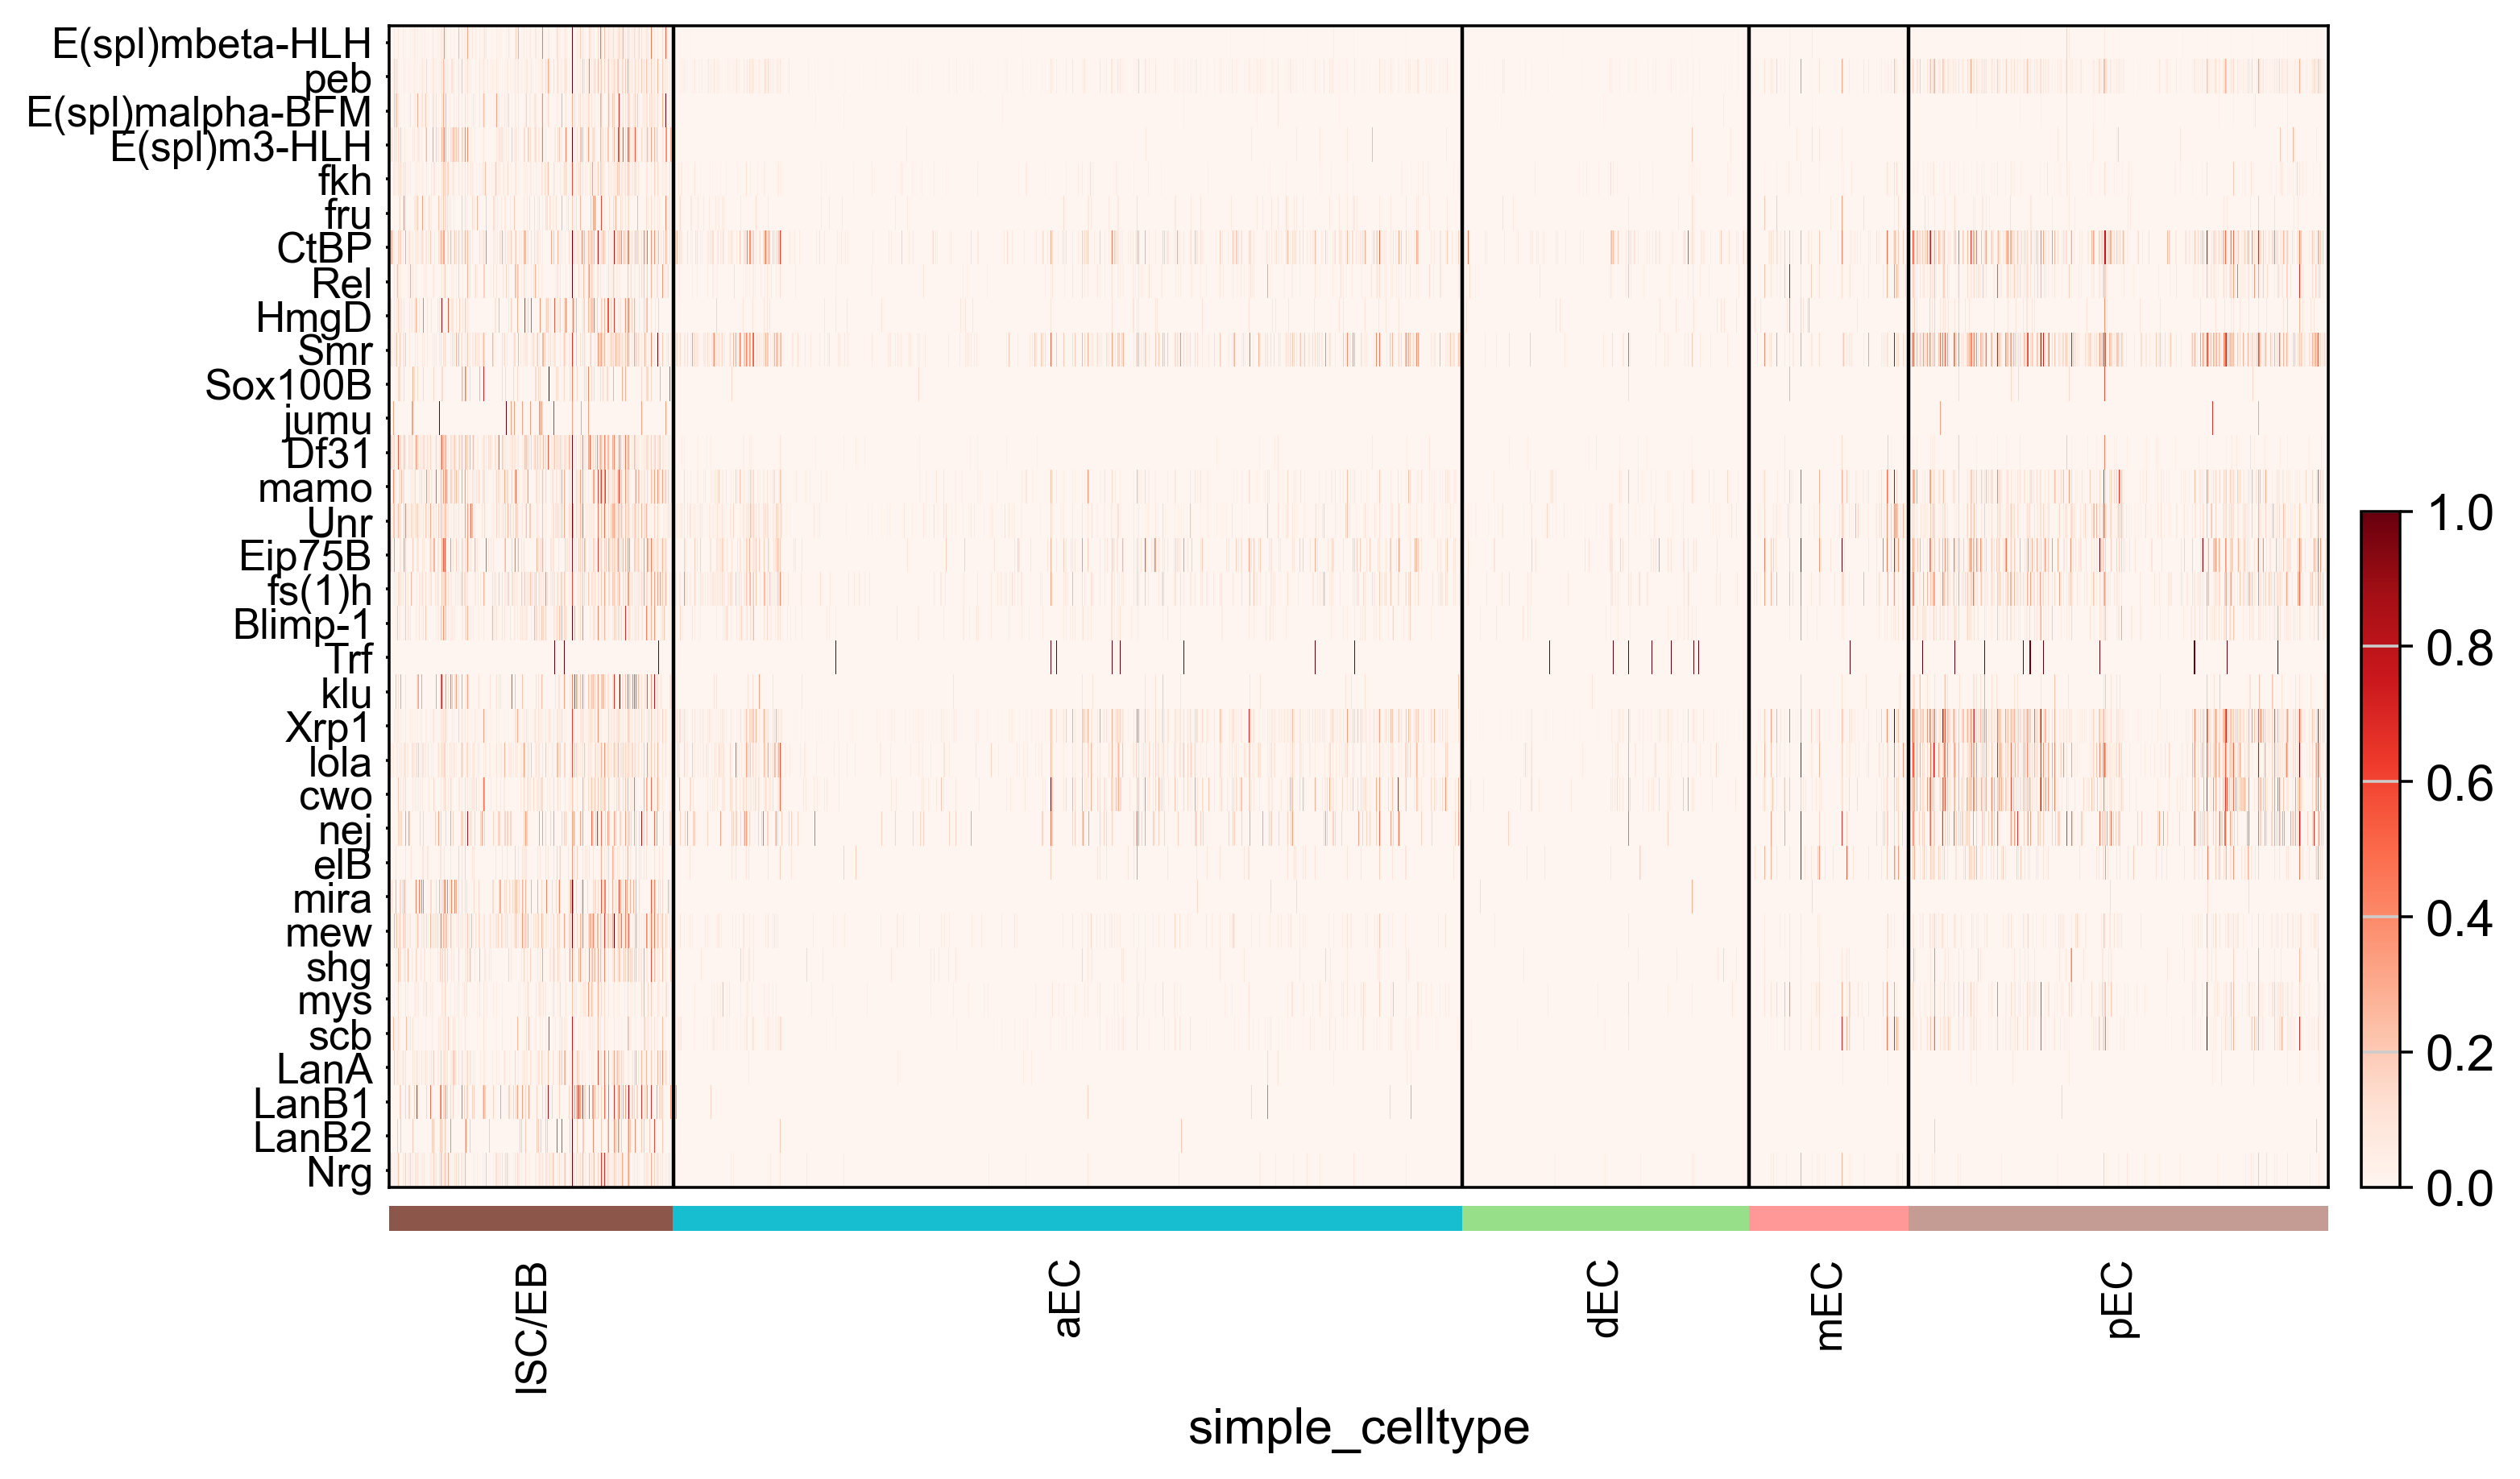

In [37]:
sc.pl.heatmap(traj,var_names=['E(spl)mbeta-HLH', 'peb', 'E(spl)malpha-BFM', 'E(spl)m3-HLH', 'fkh', 'fru', 'CtBP', 'Rel', 
                              'HmgD', 'Smr', 'Sox100B', 'jumu', 'Df31', 'mamo', 'Unr', 'Eip75B', 'fs(1)h', 'Blimp-1', 'Trf', 'klu',
                              'Xrp1', 'lola', 'cwo', 'nej', 'elB',
                              'mira', 'mew', 'shg', 'mys', 'scb', 'LanA', 'LanB1', 'LanB2', 'Nrg'], groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=1)

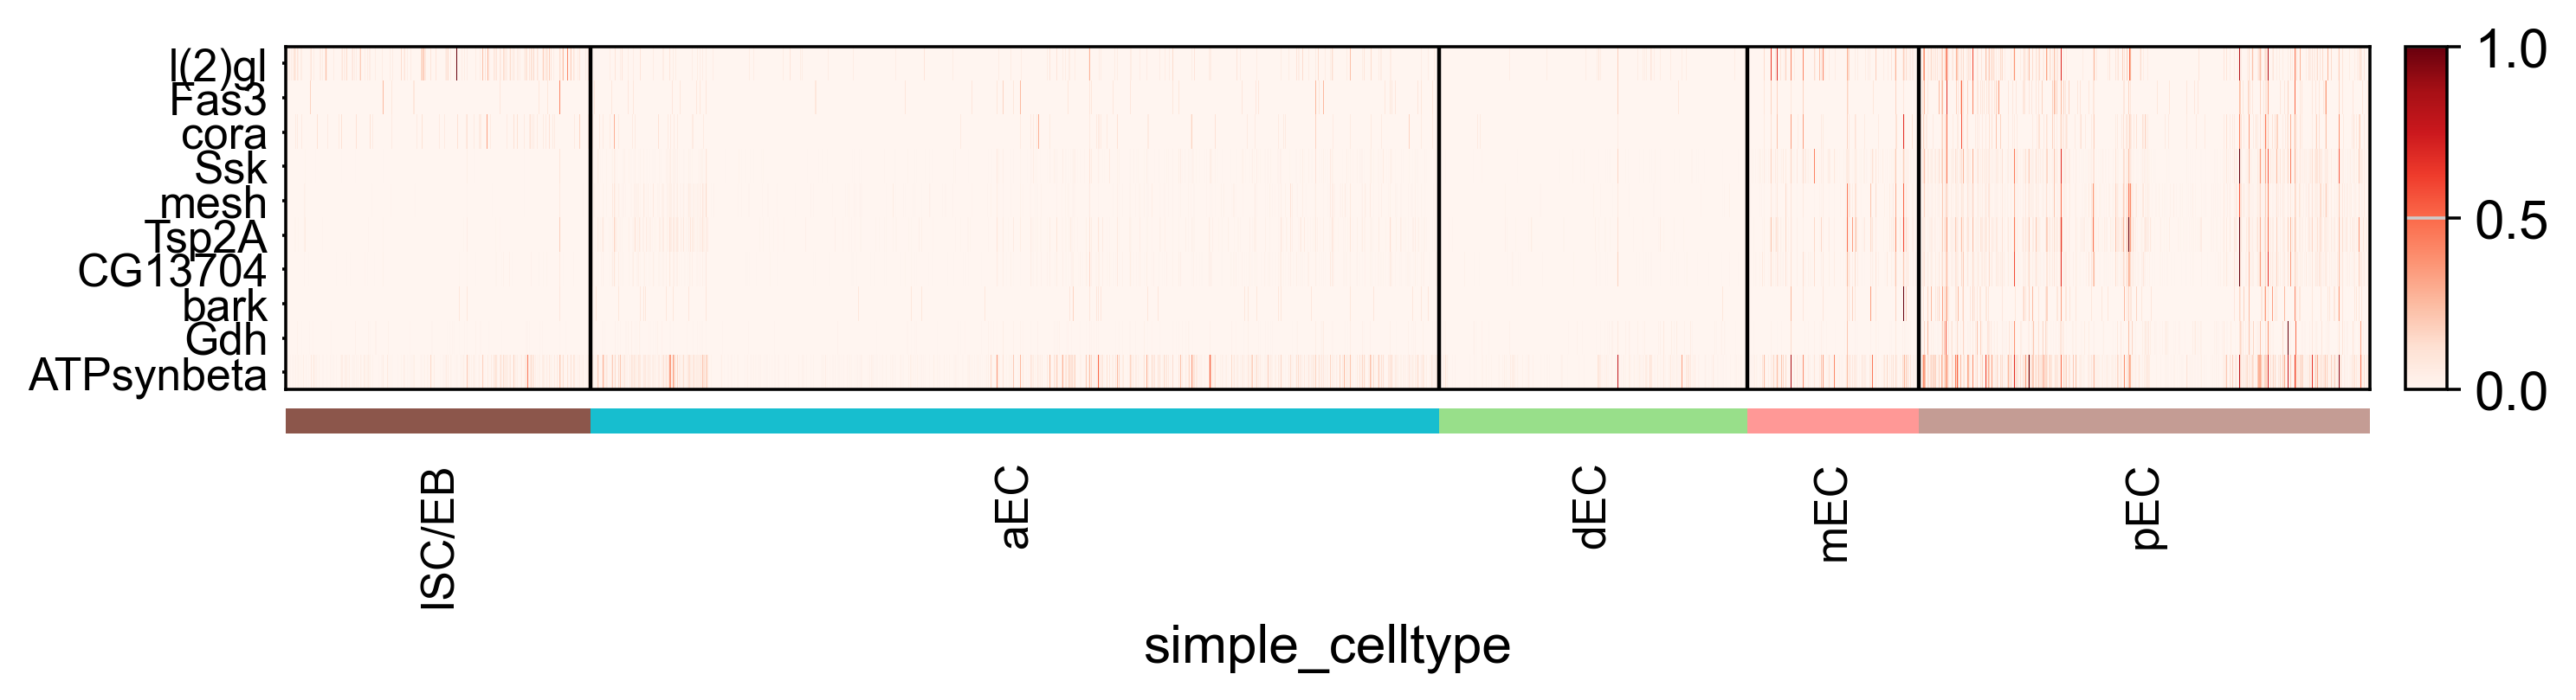

In [78]:
sc.pl.heatmap(traj,var_names=['l(2)gl', 'Fas3', 'cora', 'Ssk', 'mesh', 'Tsp2A', 'CG13704', 'bark','Gdh', 'ATPsynbeta'], 
              groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=1)

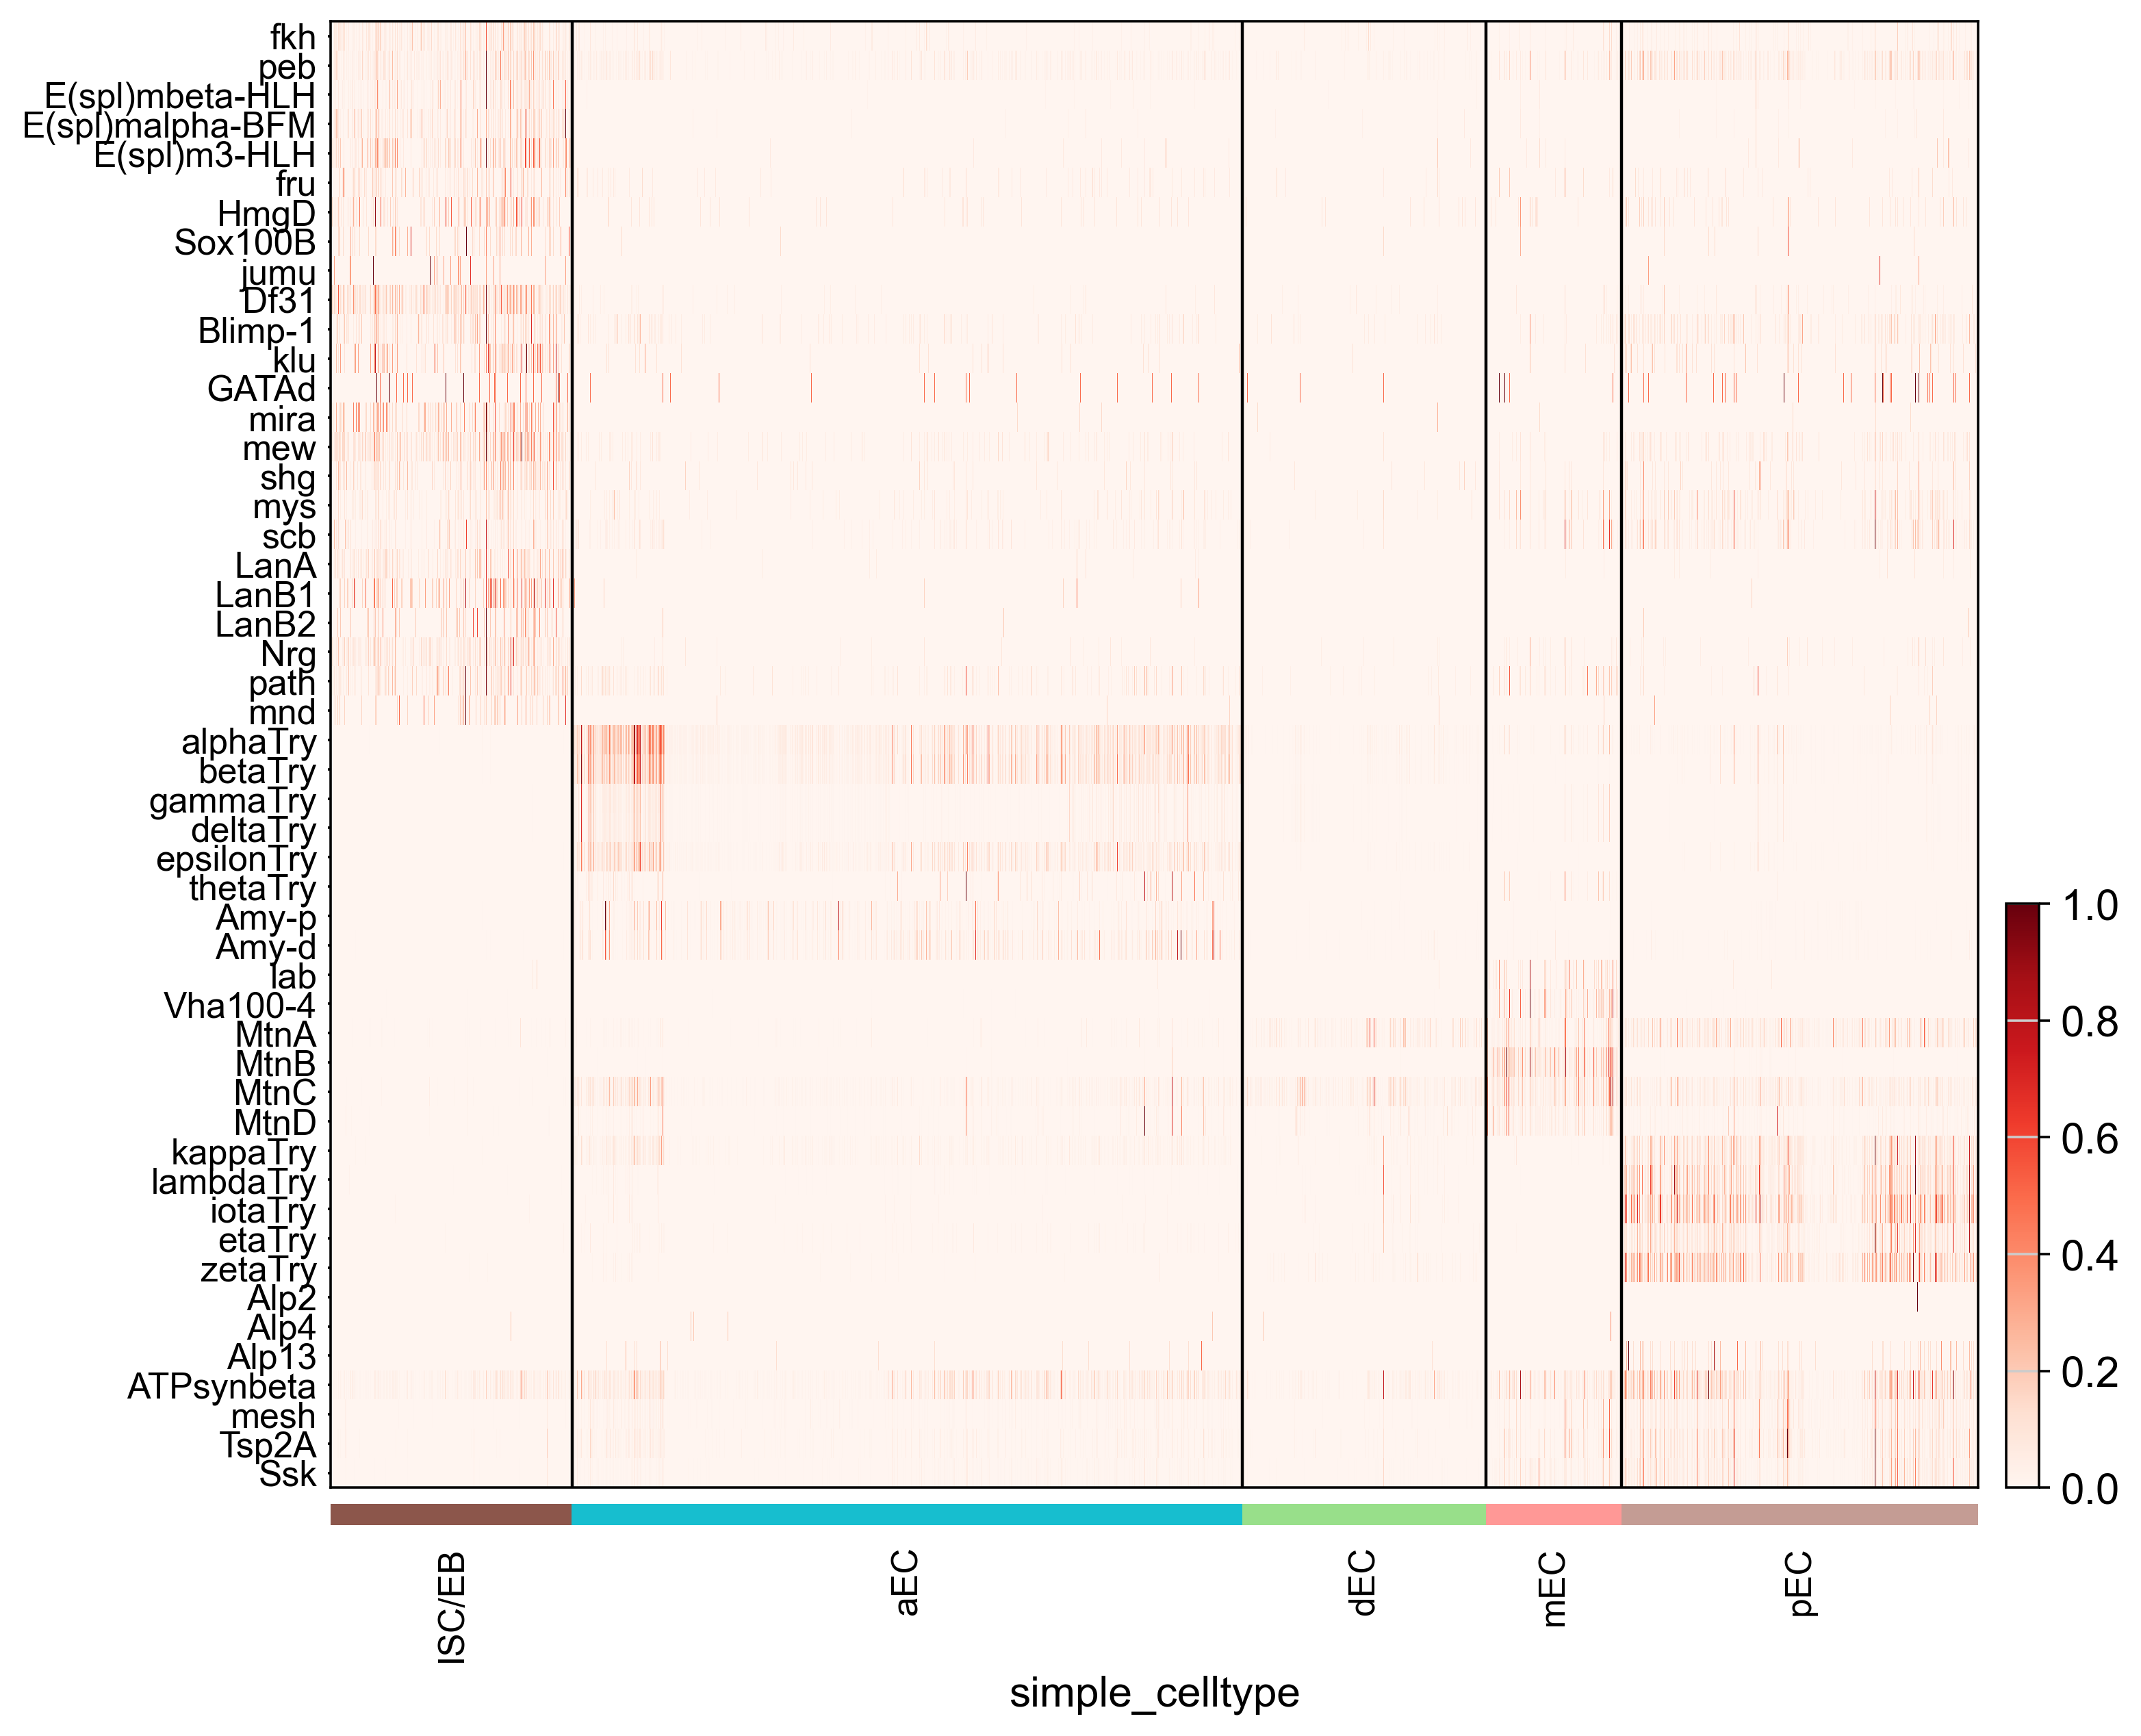

In [70]:
sc.pl.heatmap(traj,var_names=['fkh', 'peb','E(spl)mbeta-HLH', 'E(spl)malpha-BFM', 'E(spl)m3-HLH', 'fru', 
                              'HmgD', 'Sox100B', 'jumu', 'Df31', 'Blimp-1', 'klu','GATAd',
                              'mira', 'mew', 'shg', 'mys', 'scb', 'LanA', 'LanB1', 'LanB2', 'Nrg', 'path', 'mnd', 'alphaTry', 
                              'betaTry', 'gammaTry', 'deltaTry', 'epsilonTry', 'thetaTry', 'Amy-p', 'Amy-d', 
                             'lab', 'Vha100-4', 'MtnA', 'MtnB', 'MtnC', 'MtnD', 'kappaTry', 'lambdaTry', 'iotaTry', 'etaTry', 
                              'zetaTry', 'Alp2', 'Alp4', 'Alp13', 'ATPsynbeta', 'mesh', 'Tsp2A', 'Ssk'], groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=1)

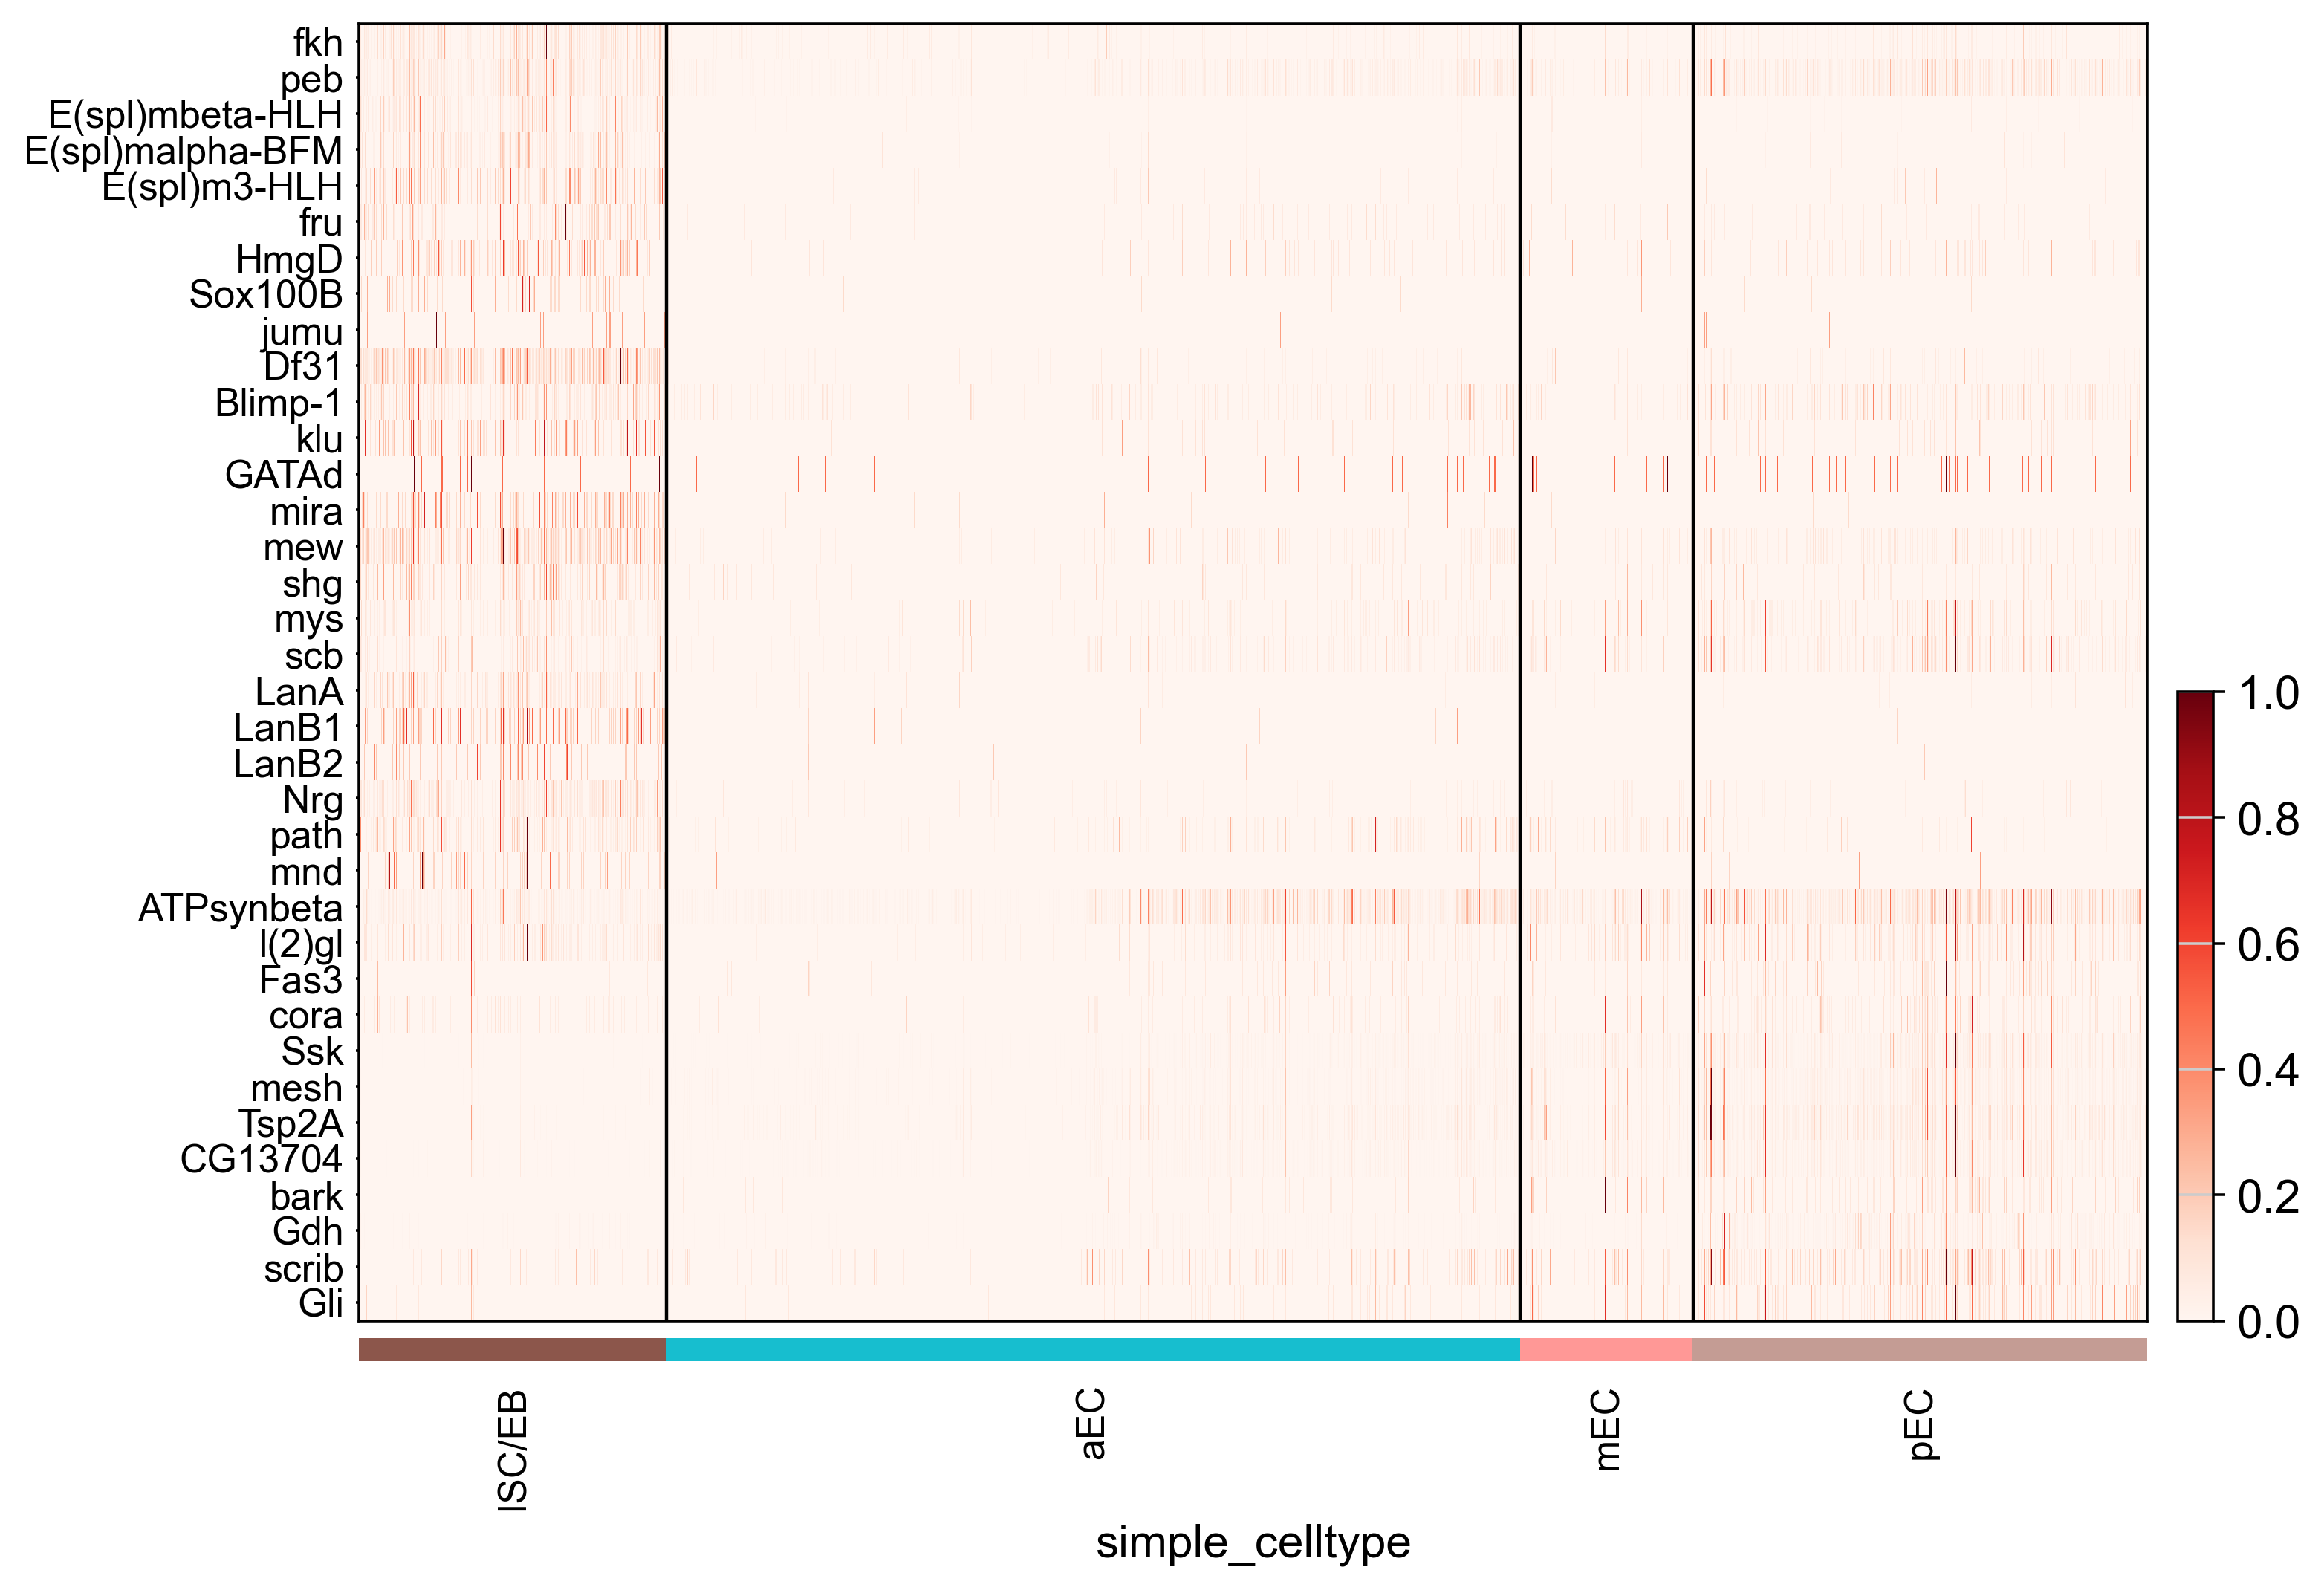

In [130]:
sc.pl.heatmap(traj,var_names=['fkh', 'peb','E(spl)mbeta-HLH', 'E(spl)malpha-BFM', 'E(spl)m3-HLH', 'fru', 
                              'HmgD', 'Sox100B', 'jumu', 'Df31', 'Blimp-1', 'klu','GATAd',
                              'mira', 'mew', 'shg', 'mys', 'scb', 'LanA', 'LanB1', 'LanB2', 
                              'Nrg', 'path', 'mnd','ATPsynbeta', 'l(2)gl', 'Fas3', 'cora', 'Ssk', 'mesh', 'Tsp2A', 'CG13704', 'bark','Gdh', 
                              'scrib', 'Gli'
                              ], groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=1, figsize=(10,7.5))

In [ ]:
Df31, mamo, Unr, Eip75B, fs(1)h, Blimp-1, Trf, klu, Xrp1, lola, cwo, nej, elB

In [28]:
module3=['CG11398',
 'ERR',
 'da',
 'CG17361',
 'E(z)',
 'Antp',
 'toe',
 'CG1647',
 'Cf2',
 'oc',
 'Doc3',
 'Hr39',
 'slp2',
 'exex',
 'CG17806',
 'bowl',
 'grn',
 'zfh1',
 'peb',
 'EcR',
 'Dek',
 'MTF-1',
 'CG13123',
 'CG17359',
 'Rbf2',
 'neur',
 'Pcl',
 'CG10669',
 'CG3281',
 'retn',
 'adp',
 'Sin3A',
 'maf-S',
 'CG2990',
 'rib',
 'vir',
 'emc',
 'Ptp99A',
 'h',
 'CG9776',
 'Dp',
 'kin17',
 'l(3)mbt',
 'Poxn',
 'cutlet',
 'dsx',
 'Pdp1',
 'CG14200',
 'spn-E',
 'CG17802',
 'fkh',
 'dup',
 'BtbVII',
 'Mlh1',
 'Ets97D',
 'btsz',
 'dac',
 'hang',
 'CG10959',
 'CG32772',
 'CG6106',
 'Meics',
 'otp',
 'ara',
 'Xpd',
 'B-H1',
 'Bap170',
 'Med',
 'dmrt11E',
 'Rel',
 'CG14451',
 'Tfb4',
 'Ssrp',
 'lz',
 'Chd3',
 'CG11906',
 'CG9650',
 'disco-r',
 'Crg-1',
 'ems',
 'dpn',
 'CG14441',
 'mei-9',
 'Tusp',
 'CG31224',
 'lid',
 'CG8108',
 'CG31460',
 'capu',
 'cyc',
 'Sox14',
 'salm',
 'sd',
 'ash2',
 'dom',
 'bigmax',
 'dan',
 'ci',
 'rn',
 'z',
 'tna',
 'grh',
 'fd96Cb',
 'CG6808',
 'CG4730',
 'opa',
 'CG11456',
 'HLH54F',
 'bi',
 'Sox21a',
 'CG31441',
 'Hmr',
 'Ubx',
 'NFAT',
 'CG30431',
 'toy',
 'CG12391',
 'CG18011',
 'phol',
 'CG2199',
 'Irbp',
 'Smr',
 'CG10462',
 'cbt',
 'HLH3B',
 'l(1)10Bb',
 'l(2)k10201',
 'jing',
 'Dfd',
 'pnt',
 'ebi',
 'RpI1',
 'tup',
 'Su(z)12',
 'Fen1',
 'Sp1',
 'cas',
 'Taf11',
 'dpa',
 'Orc1',
 'ATbp',
 'D',
 'CG10431',
 'lds',
 'pygo',
 'CG10979',
 'pho',
 'aop',
 'Top1',
 'CG4049',
 'CG9705',
 'twi',
 'brat',
 'Dll',
 'nerfin-1',
 'sima',
 'PGRP-LC',
 'CG16863',
 'Bx',
 'run',
 'CG10211',
 'esc',
 'CG11970',
 'Gnf1',
 'CG4914',
 'Mcm2',
 'CG1620',
 'Alh',
 'CG4078',
 'Pph13',
 'Scm',
 'CG3847',
 'Mef2',
 'CG3919',
 'pnr']

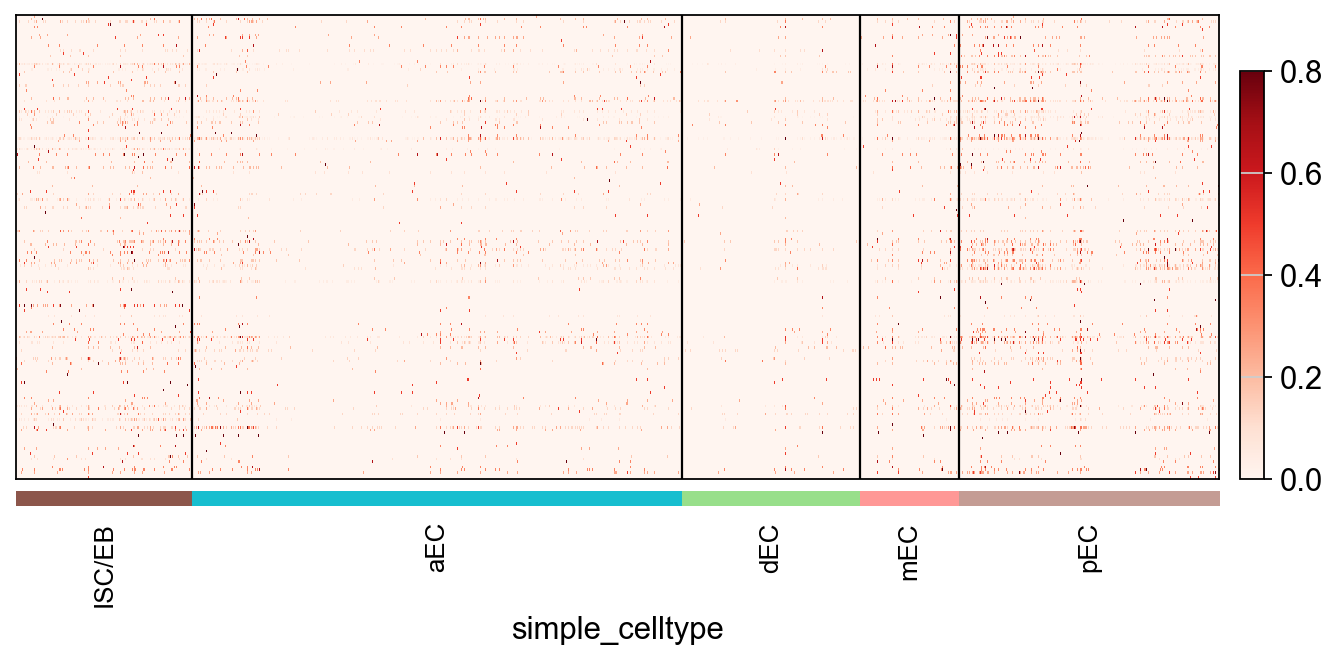

In [29]:
sc.pl.heatmap(traj,var_names=module3, groupby='simple_celltype',standard_scale='var', 
              cmap='Reds', 
              swap_axes=True, vmax=0.8)